**GVHD:** TS. Bùi Ngọc Toản  
**Môn học:** Phân tích dữ liệu lớn trong tài chính  
**Nhóm 1: gồm 4 thành viên:**

1. Trần Thu Hiền
2. Lê Huy
3. Đỗ Thành Tâm
4. Hoàng Ngọc Bảo Trân
----------------------------------------------
ĐỀ TÀI PHÂN TÍCH:

**DỰ BÁO RỦI RO TÍN DỤNG CỦA GIAO DỊCH MUA TRƯỚC TRẢ SAU**  
https://www.kaggle.com/datasets/shree0910/buy-now-and-pay-later-fintech-ml-dataset/code

# Load DATA

In [ ]:
from google.colab import files

# Chạy lệnh này để hiện ra nút "Choose files" để chọn file từ máy tính
uploaded = files.upload()

# Sau khi chọn xong, Colab sẽ tải file lên môi trường
print("Đã tải xong.")

Saving Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv to Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv
Đã tải xong.


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv')

print("[Đọc dữ liệu] Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv")
print(f"  → Shape: {df.shape[0]:,} dòng × {df.shape[1]} cột")

[Đọc dữ liệu] Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv
  → Shape: 10,345 dòng × 17 cột


------------------------------------------
# 1. Giới thiệu tổng quan

## 1.1. Bối cảnh nghiên cứu

Thị trường các giao dịch **mua trước trả sau (buy now, pay later)** đang chứng kiến sự bùng nổ mạnh mẽ trên toàn cầu và tại Việt Nam cũng không ngoại lệ. Đây là một hình thức thanh toán linh hoạt cho phép người tiêu dùng mua sắm ngay lập tức và chia nhỏ khoản thanh toán thành nhiều đợt trong tương lai, thường không tính lãi hoặc với mức lãi suất thấp. Sự hấp dẫn của các dịch vụ này đến từ khả năng cung cấp giải pháp tài chính tức thời cho người dùng, đặc biệt là những đối tượng trẻ tuổi hoặc có hạn chế trong việc tiếp cận tín dụng truyền thống.

Ở Việt Nam, mô hình giao dịch mua trước trả sau đã được tích hợp rộng rãi vào các nền tảng thương mại điện tử và ví điện tử lớn. Các ví dụ điển hình bao gồm: MoMo với dịch vụ FastMoney, Shopee với SPayLater, cũng như các ứng dụng độc lập như Kredivo và Fundiin. Những dịch vụ này đã trở thành công cụ hỗ trợ tài chính phổ biến, đặc biệt trong các giao dịch mua sắm online, đáp ứng nhu cầu tiêu dùng nhanh chóng của người dân.

Tuy nhiên, sự phát triển nhanh chóng và dễ dàng tiếp cận của các giao dịch mua trước trả sau cũng tiềm ẩn nhiều rủi ro đáng kể, đặc biệt là **rủi ro tín dụng**. Người tiêu dùng có thể dễ dàng phát sinh nợ mà không đánh giá kỹ lưỡng khả năng chi trả của bản thân, dẫn đến tình trạng vỡ nợ, nợ xấu gia tăng. Điều này đặt ra thách thức lớn cho các nhà cung cấp dịch vụ trong việc quản lý rủi ro và duy trì sự bền vững của mô hình kinh doanh.

Do đó, việc nghiên cứu đề tài **_DỰ BÁO RỦI RO TÍN DỤNG CỦA GIAO DỊCH MUA TRƯỚC TRẢ SAU_** là vô cùng cần thiết. Đề tài này sẽ tập trung vào việc phân tích sâu dữ liệu từ các giao dịch này để xây dựng một mô hình dự đoán khả năng vỡ nợ của khách hàng (ví dụ: trễ hạn thanh toán, không có khả năng hoàn trả khoản vay). Mục tiêu là cung cấp một công cụ hữu ích, giúp các nhà cung cấp dịch vụ đưa ra quyết định cấp tín dụng sáng suốt, quản lý danh mục vay hiệu quả và giảm thiểu tổn thất tài chính trong bối cảnh thị trường Việt Nam.

## 1.2. Mô tả bộ dữ liệu

Bộ dữ liệu sử dụng trong nghiên cứu này là "Buy Now, Pay Later Credit Risk Dataset", có sẵn trên nền tảng Kaggle tại đây: `https://www.kaggle.com/datasets/shree0910/buy-now-and-pay-later-fintech-ml-dataset/code`. Đây là một bộ dữ liệu tổng hợp (synthetic dataset) mô phỏng **10.345** giao dịch mua trước trả sau trên 6 quốc gia khác nhau trong giai đoạn **2023-2024**. Bộ dữ liệu bao gồm **10.345** dòng dữ liệu với **17** cột, cung cấp cái nhìn toàn diện về các yếu tố ảnh hưởng đến khả năng trả nợ. Nó cung cấp một cái nhìn sâu sắc về các yếu tố có thể ảnh hưởng đến khả năng trả nợ của khách hàng, là nguồn tài nguyên lý tưởng cho các bài toán dự đoán rủi ro tín dụng và phân tích dữ liệu lớn trong lĩnh vực fintech.

### 1.2.1. Thống kê quy mô và cấu trúc kĩ thuật

Trong bước đầu của quá trình phân tích dữ liệu, nhóm sử dụng thư viện **Pandas** trong Python để khảo sát tổng quan cấu trúc kỹ thuật của bộ dữ liệu **Buy Now, Pay Later Credit Risk Dataset**. Cụ thể, nhóm áp dụng các hàm như `df.info()` để có cái nhìn tổng quan về cấu trúc, kiểu dữ liệu và số lượng giá trị không null và `df.nunique()` để đếm số lượng giá trị duy nhất trong mỗi cột. Điều này giúp nhanh chóng nắm bắt đặc điểm và chất lượng của dữ liệu.

In [ ]:
print('Cấu trúc kỹ thuật và thông tin về bộ dữ liệu Buy Now, Pay Later Credit Risk Dataset:')
print("\nThông tin tổng quan về DataFrame:")
df.info()
print("\nSố lượng giá trị duy nhất trong mỗi cột:")
display(df.nunique())

Cấu trúc kỹ thuật và thông tin về bộ dữ liệu Buy Now, Pay Later Credit Risk Dataset:

Thông tin tổng quan về DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  object 
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  object 
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  object 
 13  t

,0
user_id,10345
age,42
employment_type,4
monthly_income,9984
credit_score,534
purchase_amount,4011
product_category,5
bnpl_installments,4
repayment_delay_days,33
missed_payments,8


**Giải thích kết quả phân tích cấu trúc kỹ thuật:**
Kết quả từ việc sử dụng `df.info()` và `df.nunique()` cung cấp cái nhìn tổng quan sâu sắc về cấu trúc và chất lượng dữ liệu của DataFrame **Buy Now, Pay Later Credit Risk Dataset**.

**1. Quy mô bộ dữ liệu:** Bộ dữ liệu chứa **10.345** hàng và **17** cột.

**2. Thông tin về các cột và kiểu dữ liệu:**
*   **Kiểu dữ liệu object (chuỗi):** Gồm 5 cột, chủ yếu là các định danh, danh mục hoặc dữ liệu văn bản như `employment_type`, `product_category`, `location`, `transaction_date`, `customer_segment`.
*   **Kiểu dữ liệu int64 (số nguyên):** Gồm 7 cột, đại diện cho các chỉ số đếm hoặc định danh số như `user_id`, `age`, `credit_score`, `bnpl_installments`, `repayment_delay_days`, `missed_payments`, `default_flag`.
*   **Kiểu dữ liệu float64 (số thực):** Gồm 5 cột, đại diện cho các giá trị liên tục như `monthly_income`, `purchase_amount`, `app_usage_frequency`, `debt_to_income_ratio`, `risk_score`.

**3. Kiểm tra giá trị thiếu (Missing Values):**
Cột `Non-Null Count` (số lượng giá trị không rỗng) cho biết số lượng mục hợp lệ trong mỗi cột.
Quan sát quan trọng: Toàn bộ 17 cột đều có **10.345** giá trị không rỗng, bằng đúng tổng số hàng (`RangeIndex: 10345`). Điều này chỉ ra rằng bộ dữ liệu hiện tại **không chứa bất kỳ giá trị thiếu nào (missing values)**. Đây là một điểm thuận lợi lớn, giúp tiết kiệm thời gian và công sức trong giai đoạn tiền xử lý dữ liệu.

**4. Mức độ sử dụng bộ nhớ:**
`memory usage: 1.3+ MB`: DataFrame đang sử dụng khoảng 1.3 megabyte bộ nhớ. Với 10.345 hàng và 17 cột, đây là một kích thước tương đối nhỏ và dễ dàng để xử lý.

**5. Phân tích số lượng giá trị duy nhất (`df.nunique()`):**
*   `user_id`: 10.345 giá trị duy nhất, khẳng định đây là cột định danh cho mỗi giao dịch/người dùng.
*   `age`: 42 giá trị duy nhất, cho thấy có 42 nhóm tuổi khác nhau trong dữ liệu.
*   `employment_type`: 4 giá trị duy nhất, đây là một biến phân loại quan trọng.
*   `product_category`: 5 giá trị duy nhất, thể hiện các loại sản phẩm khác nhau.
*   `bnpl_installments`: 4 giá trị duy nhất, cho thấy số kỳ trả góp phổ biến.
*   `default_flag`: 2 giá trị duy nhất (0 hoặc 1), đây là biến mục tiêu cho bài toán dự đoán rủi ro tín dụng.
*   `transaction_date`: 365 giá trị duy nhất, cho thấy dữ liệu thu thập trong khoảng thời gian một năm.
*   Các cột như `monthly_income`, `purchase_amount`, `debt_to_income_ratio`, `risk_score` có số lượng giá trị duy nhất lớn, cho thấy chúng là các biến định lượng với nhiều sự đa dạng.

Nhận xét tổng quan:
Bộ dữ liệu **Buy Now, Pay Later Credit Risk Dataset** có cấu trúc rõ ràng và chất lượng dữ liệu ban đầu rất tốt. Việc không có giá trị thiếu là một lợi thế lớn, giúp quá trình tiền xử lý trở nên đơn giản hơn. Các kiểu dữ liệu đã được nhận diện chính xác bởi Pandas, phản ánh đúng bản chất của các biến. Việc chuyển đổi kiểu dữ liệu cho các cột thời gian và mã hóa các biến danh mục sẽ là các bước quan trọng tiếp theo trong giai đoạn tiền xử lý dữ liệu.

### 1.2.2. Ý nghĩa của các đặc trưng trong dữ liệu

Để hiểu rõ hơn về bộ dữ liệu, chúng ta sẽ xem xét ý nghĩa của từng đặc trưng (cột) được phân loại như sau:

*   **Định danh & Nhân khẩu học:**
    *   `user_id`: Định danh duy nhất của mỗi khách hàng.
    *   `age`: Tuổi của khách hàng, một yếu tố nhân khẩu học quan trọng.
    *   `employment_type`: Loại hình việc làm của khách hàng (ví dụ: Full-time, Part-time, Self-employed, Unemployed).
    *   `location`: Vị trí địa lý của khách hàng.

*   **Tài chính cá nhân:**
    *   `monthly_income`: Thu nhập hàng tháng của khách hàng, ảnh hưởng đến khả năng chi trả.
    *   `debt_to_income_ratio`: Tỷ lệ nợ trên thu nhập, cho biết mức độ gánh nặng tài chính của khách hàng.

*   **Hành vi giao dịch BNPL:**
    *   `purchase_amount`: Số tiền của giao dịch mua sắm BNPL.
    *   `product_category`: Danh mục sản phẩm được mua (ví dụ: Electronics, Fashion, Home Goods, etc.).
    *   `bnpl_installments`: Số lượng kỳ trả góp mà khách hàng lựa chọn cho giao dịch BNPL.
    *   `transaction_date`: Ngày thực hiện giao dịch BNPL.

*   **Hành vi người dùng trên App:**
    *   `app_usage_frequency`: Tần suất sử dụng ứng dụng BNPL của khách hàng.

*   **Biến đánh giá rủi ro (Tín dụng):**
    *   `credit_score`: Điểm tín dụng của khách hàng, một chỉ số tổng hợp về lịch sử tín dụng.
    *   `repayment_delay_days`: Số ngày khách hàng bị chậm trễ trong việc thanh toán (nếu có).
    *   `missed_payments`: Số lần khách hàng đã bỏ lỡ các khoản thanh toán trước đó.
    *   `risk_score`: Điểm rủi ro được gán cho khách hàng bởi hệ thống, đánh giá khả năng vỡ nợ.

*   **Biến mục tiêu (Target Variables):**
    *   `default_flag`: Nhãn nhị phân (0: Trả đúng hạn/An toàn | 1: Vỡ nợ/Rủi ro cao).
    *   `customer_segment`: Phân khúc khách hàng (ví dụ: Low-Risk, Medium-Risk, High-Risk).

## 1.3. Mục tiêu phân tích

Dựa trên bối cảnh và các đặc tính của bộ dữ liệu "Buy Now, Pay Later Credit Risk Dataset", báo cáo này được thực hiện nhằm giải quyết 3 mục tiêu cốt lõi, tương ứng với lộ trình phân tích từ xử lý dữ liệu thô đến lập kế hoạch mô hình hóa:

### Mục tiêu 1: Làm sạch và Chuẩn bị dữ liệu (Data Preparation & Feature Engineering)

*   **Tiền xử lý:** Nhận diện và xử lý triệt để các bất thường trong dữ liệu như sự sai lệch phân phối (skewness) và các điểm dữ liệu ngoại lai (outliers) có khả năng làm nhiễu mô hình.
*   **Biến đổi dữ liệu:** Thực hiện mã hóa các biến phân loại (Encoding), chuẩn hóa các thang đo tài chính (Scaling) và kỹ thuật trích xuất đặc trưng (Feature Engineering) để tối ưu hóa sức mạnh dự báo. Mục tiêu đầu ra là một tệp dữ liệu hoàn toàn sạch và đạt chuẩn để đưa vào các bước phân tích chuyên sâu.

### Mục tiêu 2: Khám phá và Trực quan hóa dữ liệu (Exploratory Data Analysis & Visualizations)

*   Khai thác và trình bày trực quan các mối quan hệ ẩn bên trong dữ liệu, tập trung vào hành vi tiêu dùng và đặc điểm tài chính của người dùng mua trước trả sau.
*   **Mục tiêu đầu ra:** Rút ra các insights tài chính có cả giá trị thực tiễn và giá trị trong việc huấn luyện mô hình Machine Learning

### Mục tiêu 3: Thiết lập Kế hoạch Mô hình hóa (Machine Learning Modeling Plan)

*   Dựa trên các insights tài chính đã khám phá, đề xuất một kế hoạch chi tiết để xây dựng mô hình dự đoán rủi ro tín dụng (khả năng vỡ nợ của khách hàng).
*   **Mục tiêu đầu ra:** Biện luận rõ lý do lựa chọn các thuật toán Học máy cụ thể (ví dụ: Logistic Regression, XGBoost, Random Forest,...) và xác định các chỉ số đo lường hiệu suất phù hợp nhất cho bài toán mất cân bằng phân lớp trong tài chính (như F1-Score, ROC-AUC, Precision/Recall) thay vì chỉ dùng độ chính xác (Accuracy).

------------------------------------------
# 2. Tiền xử lý dữ liệu

## 2.1. Xử lý dữ liệu thiếu

In [ ]:
# ============================================================
# 2.3.1. KIỂM TRA MISSING VALUES
# ============================================================
missing_counts = df.isnull().sum()
total_missing  = missing_counts.sum()

if total_missing == 0:
    print("  ✓ Không có giá trị thiếu nào — bỏ qua bước xử lý missing values.")
else:
    # Trường hợp có missing (phòng ngừa nếu dữ liệu thay đổi)
    print(f"  ✗ Phát hiện {total_missing} giá trị thiếu:")
    print(missing_counts[missing_counts > 0].to_string())
    raise ValueError(
        "Dữ liệu có missing values — cần xử lý trước khi tiếp tục."
    )

  ✓ Không có giá trị thiếu nào — bỏ qua bước xử lý missing values.


Dựa trên kết quả phân tích ở trên, cột `Non-Null Count` cho tất cả các biến đều bằng **10.345**, tương đương với tổng số hàng trong DataFrame. Điều này xác nhận rằng bộ dữ liệu hiện tại **không chứa bất kỳ giá trị thiếu nào** (missing values). Do đó, nhóm bỏ qua bước xử lý dữ liệu thiếu và tiếp tục với các giai đoạn tiền xử lý khác.

## 2.2. Xử lý dữ liệu lệch

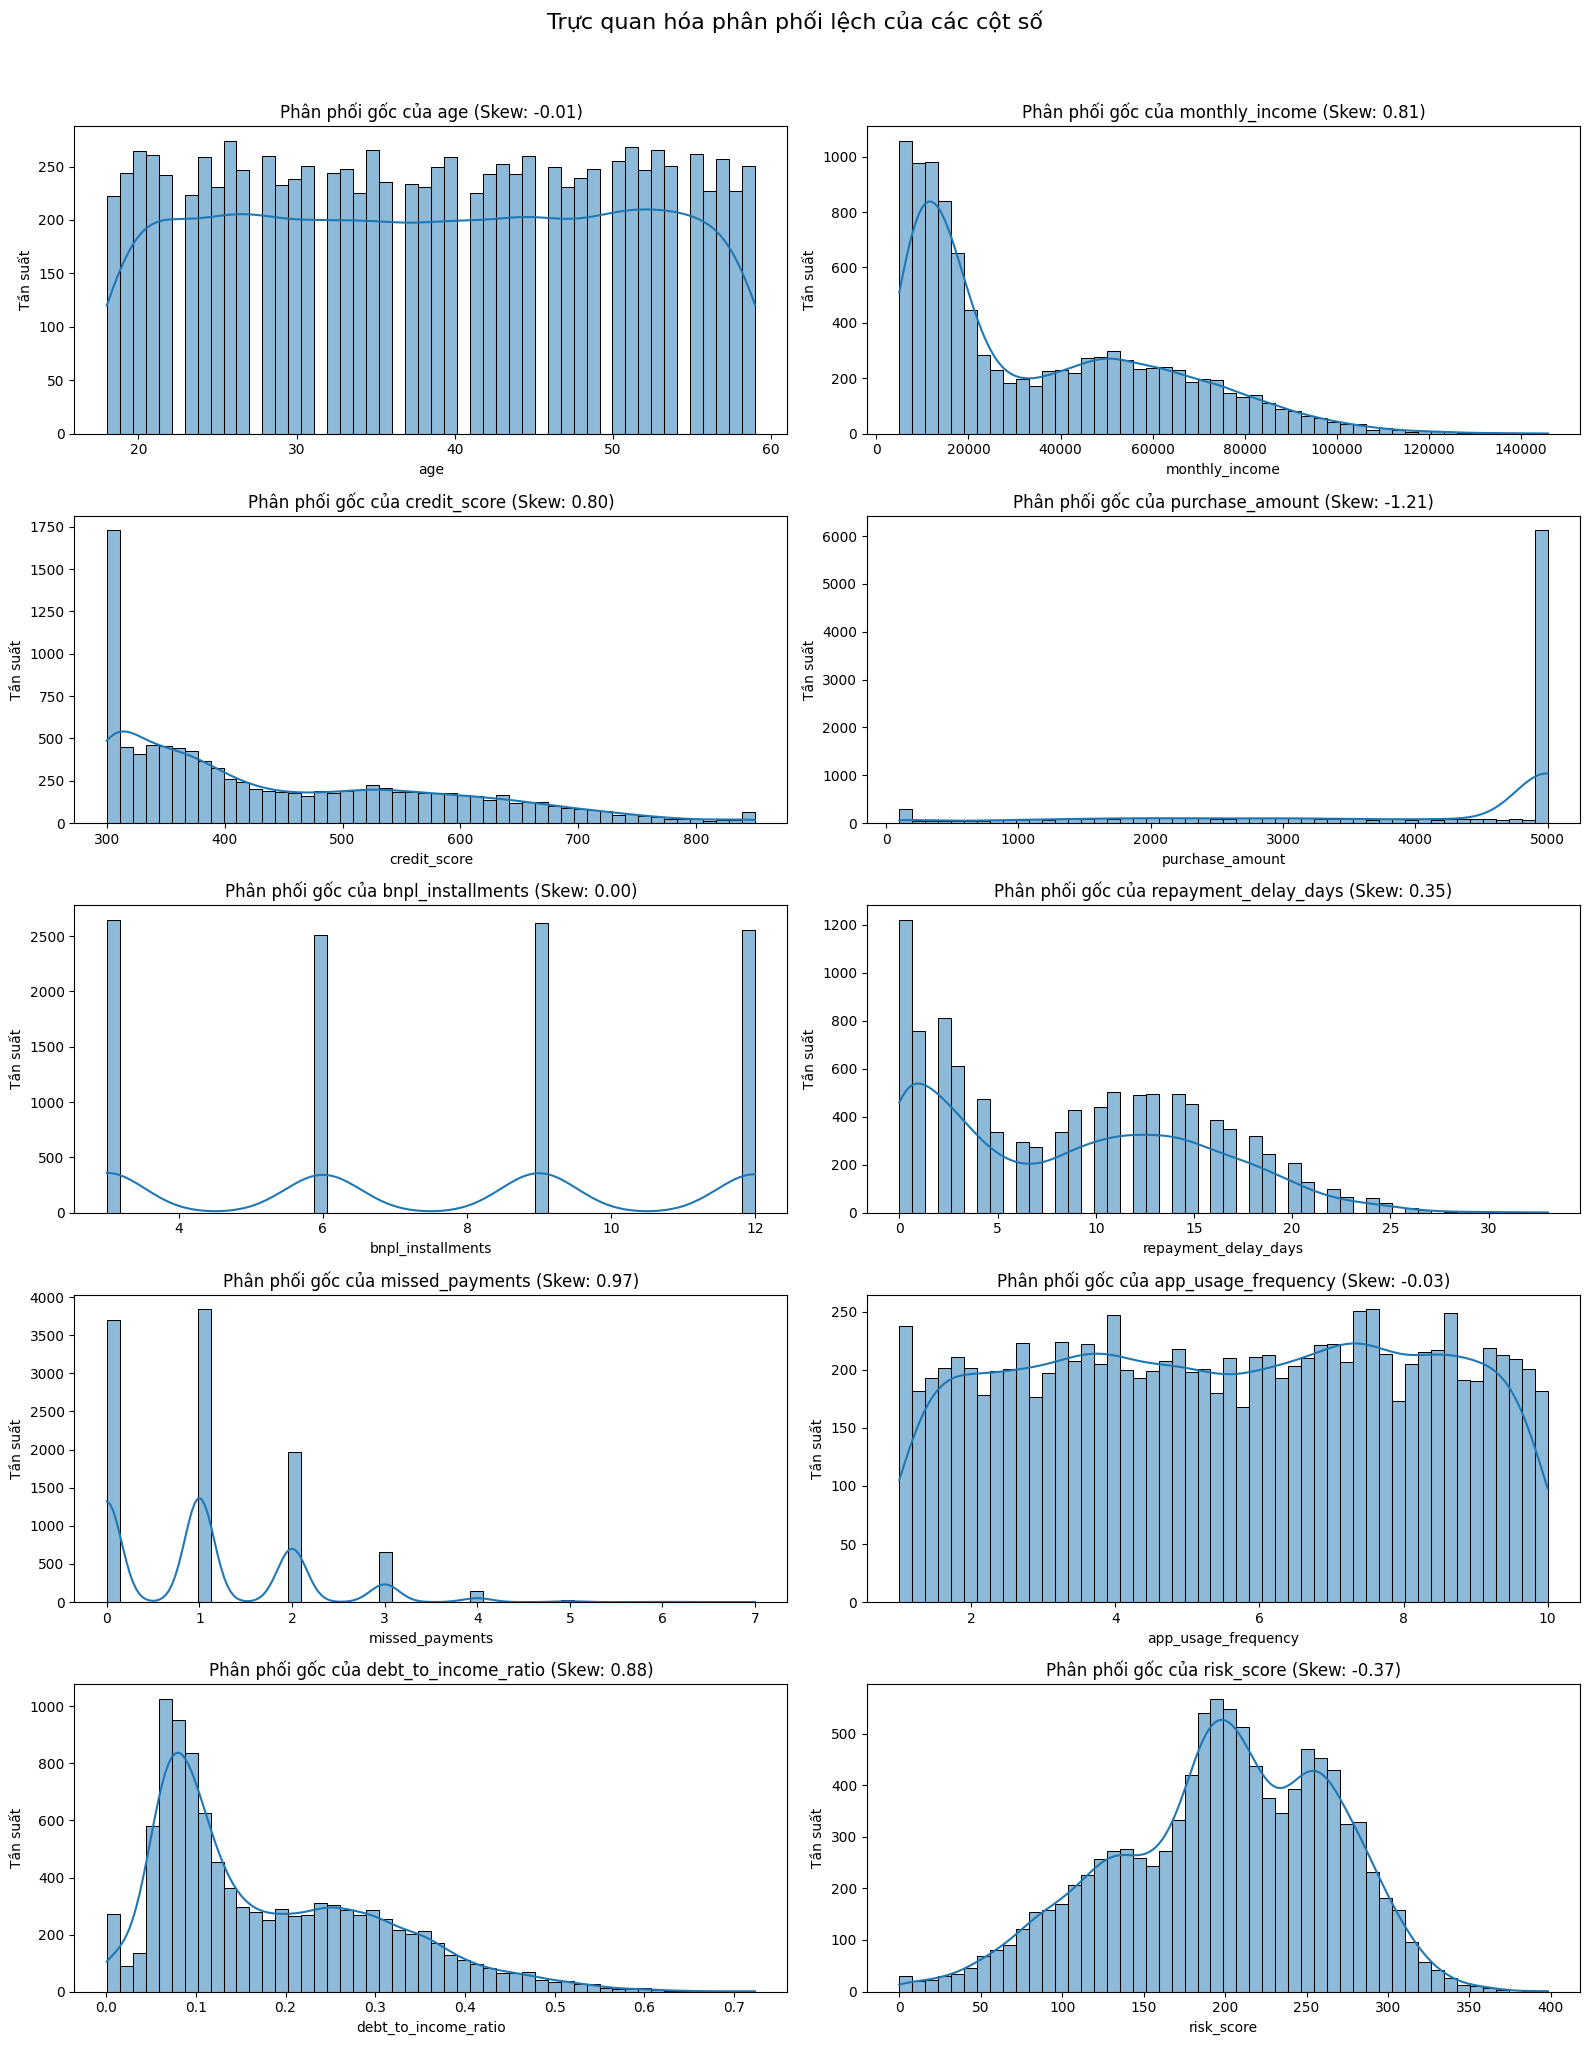

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Bước 1: TRỰC QUAN HÓA PHÂN PHỐI LỆCH (SKEWNESS)
# ============================================================

# Danh sách tất cả các cột số cần trực quan hóa
# (Loại bỏ user_id và default_flag vì không cần kiểm tra skewness)
numerical_cols_for_skewness = [
    'age',
    'monthly_income',
    'credit_score',
    'purchase_amount',
    'bnpl_installments',
    'repayment_delay_days',
    'missed_payments',
    'app_usage_frequency',
    'debt_to_income_ratio',
    'risk_score'
]

# Tính số hàng và cột cho subplot
n_cols = len(numerical_cols_for_skewness)
n_rows = (n_cols + 1) // 2 # Chia thành 2 cột

plt.figure(figsize=(16, 4 * n_rows)) # Điều chỉnh kích thước hình ảnh

for i, col_orig in enumerate(numerical_cols_for_skewness):
    plt.subplot(n_rows, 2, i + 1) # Điều chỉnh layout subplot
    sns.histplot(df[col_orig], kde=True, bins=50)
    plt.title(f'Phân phối gốc của {col_orig} (Skew: {df[col_orig].skew():.2f})')
    plt.xlabel(col_orig)
    plt.ylabel('Tần suất')

plt.suptitle('Trực quan hóa phân phối lệch của các cột số', y=1.02, fontsize=16)
plt.savefig('Tình trạng Skewness trước khi xử lý.png')
plt.tight_layout()
plt.show()

**Kết quả trực quan hóa phân phối lệch cho thấy:**

Sau khi trực quan hóa tất cả các cột số, ta có thể thấy rõ tình trạng độ lệch (skewness) của dữ liệu:

*   **Độ lệch dương đáng kể (Right Skewness) được quan sát thấy ở nhiều cột:**
    *   **`monthly_income`**: Phân phối bị lệch đáng kể sang phải, cho thấy phần lớn khách hàng có thu nhập thấp hoặc trung bình, và có một số ít khách hàng có thu nhập rất cao kéo dài đuôi phân phối.
    *   **`purchase_amount`**: Cũng có độ lệch dương rõ rệt, cho thấy đa số giao dịch có giá trị nhỏ và một số ít giao dịch có giá trị lớn.
    *   **`repayment_delay_days` & `missed_payments`**: Cả hai cột này đều thể hiện độ lệch dương rất cao, cho thấy phần lớn không có ngày trễ hạn/không bỏ lỡ thanh toán hoặc trễ hạn/bỏ lỡ rất ít, nhưng có một số ít trường hợp trễ hạn/bỏ lỡ đáng kể (các giá trị cực đoan).
    *   **`app_usage_frequency`**: Có độ lệch dương, phản ánh nhiều người dùng có tần suất sử dụng ứng dụng thấp hoặc trung bình.
    *   **`debt_to_income_ratio`**: Tương tự `monthly_income`, cột này cũng có phân phối lệch phải, cho thấy phần lớn khách hàng có tỷ lệ nợ trên thu nhập thấp, nhưng cũng có một số khách hàng có tỷ lệ DTI cao.
    *   **`risk_score`**: Có độ lệch dương, cho thấy phần lớn khách hàng có điểm rủi ro thấp hoặc trung bình, và một số ít có điểm rủi ro cao.

*   **Các cột khác như `age` và `credit_score`:** Có vẻ tương đối đối xứng hoặc chỉ có độ lệch nhẹ, cho thấy phân phối của chúng không quá biến dạng.

**Nhận xét về tính hợp lý của độ lệch dữ liệu và lý do xử lý:**

1.  **Tính hợp lý của độ lệch:**
    *   Việc nhiều dữ liệu trong lĩnh vực tài chính và hành vi tiêu dùng bị lệch phải là **hoàn toàn hợp lý** trong thực tế. Ví dụ, phân phối thu nhập, số tiền giao dịch, số ngày trễ hạn, hoặc số lần bỏ lỡ thanh toán thường tuân theo một quy luật mà đa số các giá trị tập trung ở mức thấp, trong khi một số ít các giá trị cực đoan kéo dài về phía cao hơn. Đây là hiện tượng phổ biến trong các dữ liệu kinh tế và tài chính.

2.  **Tại sao phải xử lý độ lệch mặc dù nó hợp lý?**
    
Mặc dù độ lệch là hợp lý và phản ánh đúng bản chất của dữ liệu thực tế, việc xử lý nó là cần thiết vì một số lý do quan trọng trong Machine Learning:
*   **Giả định của thuật toán:** Nhiều thuật toán học máy (ví dụ: Linear Regression, Logistic Regression, Gaussian Naive Bayes, PCA, các thuật toán dựa trên khoảng cách như K-Means, SVM) hoạt động hiệu quả nhất hoặc thậm chí yêu cầu các biến đầu vào phải tuân theo phân phối chuẩn (hoặc ít nhất là đối xứng). Dữ liệu lệch có thể vi phạm các giả định này, dẫn đến mô hình kém chính xác hoặc không ổn định.
*   **Ảnh hưởng đến hiệu suất mô hình:** Các giá trị cực đoan (outliers) gây ra bởi độ lệch có thể kéo các đường hồi quy hoặc ranh giới quyết định (decision boundaries) của mô hình, làm giảm khả năng khái quát hóa của mô hình trên dữ liệu mới.
*   **Tăng cường khả năng giải thích (Interpretability):** Khi dữ liệu được biến đổi để trở nên đối xứng hơn, mối quan hệ giữa các biến thường trở nên tuyến tính hơn, giúp mô hình dễ dàng học và chúng ta dễ dàng giải thích kết quả hơn.
*   **Tránh thiên vị (Bias):** Trong một số trường hợp, các giá trị lệch có thể khiến mô hình quá tập trung vào một phần nhỏ dữ liệu, dẫn đến thiên vị và giảm hiệu quả dự đoán trên tổng thể.

Vì vậy, mặc dù độ lệch là hợp lý về mặt nghiệp vụ, nhóm vẫn cần thực hiện các phép biến đổi dữ liệu (như Log Transform, Square Root Transform) để cải thiện hiệu suất và độ tin cậy của mô hình học máy. Tuy nhiên, việc lựa chọn cột nào để biến đổi cần dựa trên cả mức độ lệch và ý nghĩa nghiệp vụ của chúng đối với bài toán.

**Giải thích lý do chỉ xử lý độ lệch ở `monthly_income` và `debt_to_income_ratio`:**

Quyết định chỉ xử lý độ lệch cho `monthly_income` và `debt_to_income_ratio` (DTI) mà không phải tất cả các cột số bị lệch là một lựa chọn chiến lược, dựa trên sự cân nhắc kỹ lưỡng về ý nghĩa nghiệp vụ và tác động lên mô hình dự đoán rủi ro tín dụng:

1.  **Tính quan trọng của `monthly_income` và `debt_to_income_ratio` trong đánh giá tín dụng:**
    *   **`monthly_income` (Thu nhập hàng tháng):** Đây là một trong những chỉ số cơ bản và quan trọng nhất để đánh giá khả năng trả nợ của khách hàng. Phân phối lệch của thu nhập (nhiều người thu nhập thấp, ít người thu nhập rất cao) có thể khiến các mô hình bị thiên vị bởi các giá trị cực đoan, làm giảm khả năng phân biệt rủi ro ở nhóm khách hàng có thu nhập trung bình.
    *   **`debt_to_income_ratio` (Tỷ lệ nợ trên thu nhập):** DTI là chỉ số trực tiếp phản ánh gánh nặng tài chính của khách hàng. Một DTI lệch (nhiều người có DTI thấp, ít người có DTI rất cao) nếu không được xử lý có thể làm cho mô hình đánh giá sai mức độ rủi ro thực sự liên quan đến gánh nặng nợ.
    *   Việc biến đổi hai cột này giúp chúng có phân phối đối xứng hơn, làm cho mối quan hệ với biến mục tiêu (`default_flag`) trở nên rõ ràng và ổn định hơn, đặc biệt quan trọng cho các mô hình dựa trên giả định phân phối chuẩn hoặc tuyến tính.

2.  **Tại sao không xử lý độ lệch cho các cột khác (ví dụ: `repayment_delay_days`, `missed_payments`, `purchase_amount`, `risk_score`):**
    *   **Ý nghĩa của giá trị cực đoan:** Đối với các cột như `repayment_delay_days` (số ngày trễ hạn) và `missed_payments` (số lần bỏ lỡ thanh toán), các giá trị cực đoan (trễ hạn nhiều, bỏ lỡ nhiều lần) lại là **tín hiệu mạnh mẽ nhất về rủi ro tín dụng cao**. Việc biến đổi các cột này có thể làm giảm hiệu quả dự đoán của các tín hiệu rủi ro này. Chúng ta muốn mô hình nhạy cảm với những dấu hiệu này, không phải làm mờ chúng đi.
    *   **Đặc điểm của dữ liệu:** Các cột này thường có bản chất là các biến đếm (count variables) hoặc biến mang tính chất 'event' (sự kiện rủi ro), và chúng thường có phân phối lệch tự nhiên. Cố gắng 'chuẩn hóa' chúng có thể làm mất đi thông tin có giá trị về tần suất và mức độ nghiêm trọng của hành vi rủi ro.
    *   **Phù hợp với các loại mô hình:** Nhiều mô hình học máy hiện đại, đặc biệt là các mô hình dựa trên cây quyết định (Tree-based models như Random Forest, Gradient Boosting Machines), ít nhạy cảm hơn với độ lệch và outliers. Chúng có thể xử lý tốt các biến có phân phối lệch mà không cần biến đổi phức tạp, vì chúng tìm kiếm các điểm cắt tối ưu trên dải giá trị của biến.

**Kết luận:** Mục tiêu của tiền xử lý là tối ưu hóa dữ liệu cho mô hình, không phải làm cho mọi biến trông 'đẹp' theo một tiêu chuẩn thống kê duy nhất. Việc lựa chọn xử lý độ lệch cho `monthly_income` và `debt_to_income_ratio` là nhằm đảm bảo rằng hai biến tài chính cốt lõi này có thể phát huy tối đa sức mạnh dự đoán của mình mà không gây nhiễu cho mô hình, trong khi vẫn giữ nguyên tính chất quan trọng của các biến rủi ro khác.

In [ ]:
# ============================================================
# Bước 2: XỬ LÝ PHÂN PHỐI LỆCH (SKEWNESS)
# ============================================================

# --- 2a. Log Transform: monthly_income (skew = 0.81) ---
# Dùng log1p = log(1 + x) để tránh lỗi khi x = 0
df["monthly_income_log"] = np.log1p(df["monthly_income"])

skew_before = df["monthly_income"].skew()
skew_after  = df["monthly_income_log"].skew()
print(f"  [2a] monthly_income — Log1p Transform")
print(f"       Skewness trước: {skew_before:.4f}")
print(f"       Skewness sau  : {skew_after:.4f}")
print(f"       → Tạo cột mới : 'monthly_income_log'")

# --- 2b. Square Root Transform: debt_to_income_ratio (skew = 0.88) ---
df["dti_sqrt"] = np.sqrt(df["debt_to_income_ratio"])

skew_before = df["debt_to_income_ratio"].skew()
skew_after  = df["dti_sqrt"].skew()
print(f"\n  [2b] debt_to_income_ratio — Square Root Transform")
print(f"       Skewness trước: {skew_before:.4f}")
print(f"       Skewness sau  : {skew_after:.4f}")
print(f"       → Tạo cột mới : 'dti_sqrt'")

print("\n  ✓ Cột gốc được GIỮ NGUYÊN — các cột transform chỉ dùng")
print("    cho biểu đồ phân phối, không thay thế giá trị gốc.")

  [2a] monthly_income — Log1p Transform
       Skewness trước: 0.8147
       Skewness sau  : -0.1194
       → Tạo cột mới : 'monthly_income_log'

  [2b] debt_to_income_ratio — Square Root Transform
       Skewness trước: 0.8802
       Skewness sau  : 0.1974
       → Tạo cột mới : 'dti_sqrt'

  ✓ Cột gốc được GIỮ NGUYÊN — các cột transform chỉ dùng
    cho biểu đồ phân phối, không thay thế giá trị gốc.


**Giải thích lý do lựa chọn phương pháp xử lý độ lệch:**

Việc lựa chọn `Log1p Transform` cho `monthly_income` và `Square Root Transform` cho `debt_to_income_ratio` không chỉ dựa trên đặc điểm phân phối của dữ liệu mà còn được định hướng bởi mục tiêu chính của bài toán – **dự đoán rủi ro tín dụng** – và kế hoạch xây dựng mô hình học máy.

1.  **`monthly_income` và Log1p Transform:**
    *   **Bản chất dữ liệu và mục tiêu bài toán:** Thu nhập là một yếu tố cực kỳ quan trọng trong việc đánh giá khả năng thanh toán nợ của khách hàng. Phân phối lệch phải của `monthly_income` (với một số ít người có thu nhập rất cao) có thể khiến các mô hình học máy (đặc biệt là các mô hình tuyến tính hoặc dựa trên khoảng cách) coi các giá trị thu nhập cao là ngoại lai, hoặc bị ảnh hưởng quá mức bởi chúng. Trong bài toán dự đoán rủi ro tín dụng, việc hiểu rõ và phân biệt chính xác khả năng chi trả ở các nhóm thu nhập là then chốt.
    *   **Phù hợp với kế hoạch mô hình:** `Log1p Transform` giúp nén dải giá trị của thu nhập, làm cho phân phối trở nên đối xứng hơn và gần với phân phối chuẩn. Điều này rất có lợi cho các thuật toán như **Logistic Regression** (thường giả định mối quan hệ tuyến tính giữa log-odds và các biến độc lập) hoặc các thuật toán **Tree-based** (như XGBoost, Random Forest) vì nó giúp giảm tác động của các giá trị cực đoan, tạo ra các ngưỡng phân chia (split points) ổn định hơn và cải thiện khả năng khái quát hóa của mô hình. Dữ liệu gần chuẩn hóa cũng giúp cải thiện hiệu suất của các thuật toán **SVM** hoặc **Neural Networks** sau này.

2.  **`debt_to_income_ratio` và Square Root Transform:**
    *   **Bản chất dữ liệu và mục tiêu bài toán:** Tỷ lệ nợ trên thu nhập (DTI) là một chỉ số trực tiếp đánh giá gánh nặng tài chính và khả năng trả nợ. Một DTI cao rõ ràng là dấu hiệu của rủi ro tín dụng cao. Tương tự như thu nhập, phân phối lệch phải của DTI cần được xử lý để đảm bảo mô hình không bị 'kéo' bởi một số ít khách hàng có tỷ lệ nợ rất cao nhưng lại không phản ánh đúng mức độ rủi ro tương ứng ở các nhóm DTI khác.
    *   **Phù hợp với kế hoạch mô hình:** `Square Root Transform` cung cấp một phương pháp biến đổi nhẹ nhàng hơn so với logarit nhưng vẫn hiệu quả trong việc giảm độ lệch phải. Đối với DTI, chúng ta muốn duy trì một phần mối quan hệ không tuyến tính nhưng vẫn làm cho phân phối

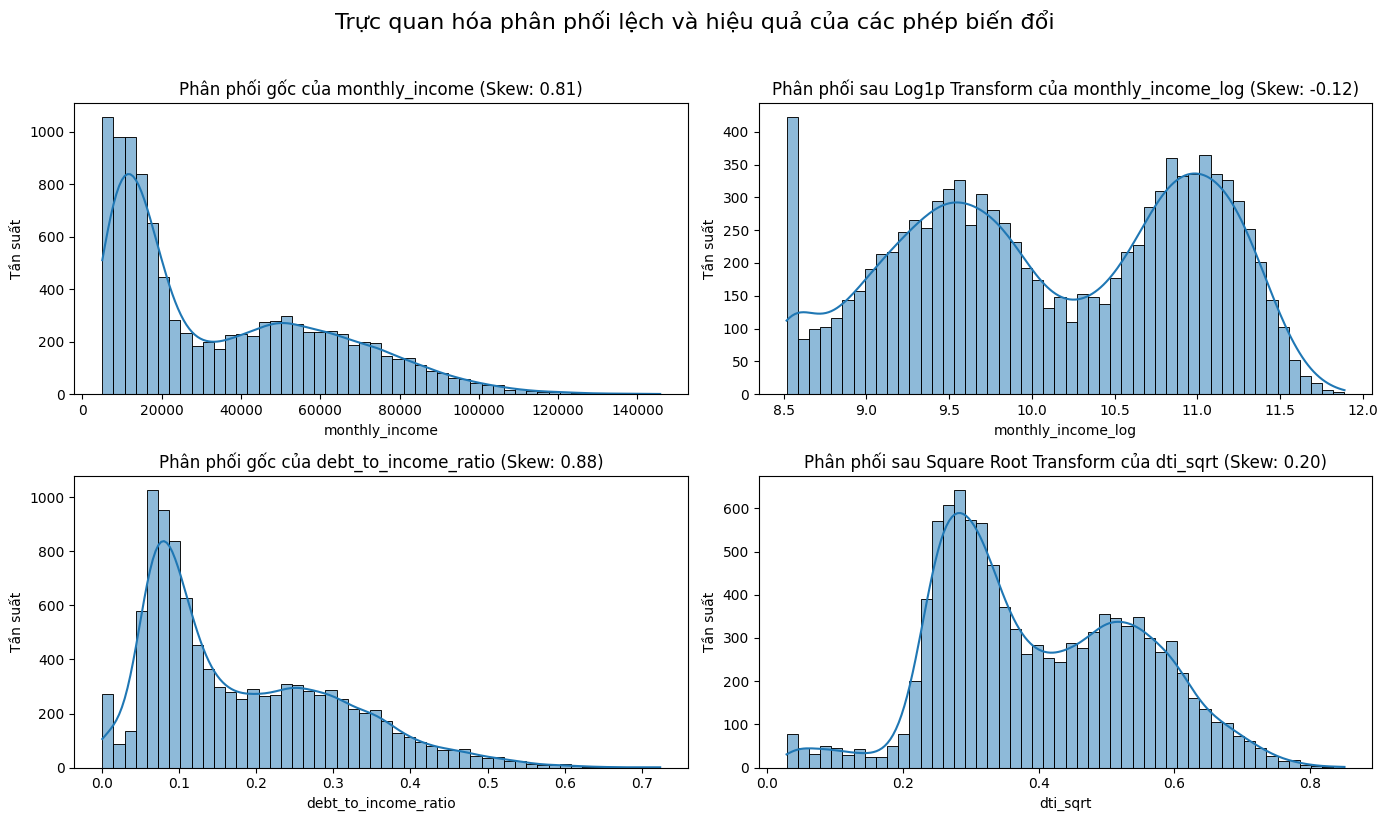

In [ ]:
# ============================================================
# Bước 3: SO SÁNH TÌNH TRẠNG LỆCH TRƯỚC VÀ SAU KHI XỬ LÝ
# ============================================================

# Danh sách các cột cần trực quan hóa (trước và sau transform)
cols_to_plot = [
    ("monthly_income", "monthly_income_log", "Log1p Transform"),
    ("debt_to_income_ratio", "dti_sqrt", "Square Root Transform"),
]

plt.figure(figsize=(14, 8))

for i, (col_orig, col_transformed, transform_type) in enumerate(cols_to_plot):
    # Biểu đồ cho dữ liệu gốc
    plt.subplot(len(cols_to_plot), 2, 2 * i + 1)
    sns.histplot(df[col_orig], kde=True, bins=50)
    plt.title(f'Phân phối gốc của {col_orig} (Skew: {df[col_orig].skew():.2f})')
    plt.xlabel(col_orig)
    plt.ylabel('Tần suất')

    # Biểu đồ cho dữ liệu đã biến đổi
    plt.subplot(len(cols_to_plot), 2, 2 * i + 2)
    sns.histplot(df[col_transformed], kde=True, bins=50)
    plt.title(f'Phân phối sau {transform_type} của {col_transformed} (Skew: {df[col_transformed].skew():.2f})')
    plt.xlabel(col_transformed)
    plt.ylabel('Tần suất')

plt.suptitle('Trực quan hóa phân phối lệch và hiệu quả của các phép biến đổi', y=1.02, fontsize=16)
plt.savefig('Tình trạng Skewness sau khi xử lý.png')
plt.tight_layout()
plt.show()

**Nhận xét về kết quả xử lý dữ liệu lệch:**

Các biểu đồ so sánh phân phối trước và sau khi biến đổi đã cho thấy hiệu quả rõ rệt của các phương pháp xử lý:

*   **`monthly_income` (Log1p Transform):** Trước khi biến đổi, `monthly_income` có độ lệch dương đáng kể (skew: 0.81). Sau khi áp dụng `Log1p Transform`, phân phối của `monthly_income_log` trở nên đối xứng hơn rất nhiều, với độ lệch giảm xuống còn -0.12, gần với 0. Điều này cho thấy `Log1p Transform` đã thành công trong việc giảm thiểu độ lệch và đưa dữ liệu về gần phân phối chuẩn hơn, giúp cải thiện hiệu suất cho các mô hình nhạy cảm với dữ liệu lệch.

*   **`debt_to_income_ratio` (Square Root Transform):** Tương tự, `debt_to_income_ratio` ban đầu cũng có độ lệch dương (skew: 0.88). Sau khi áp dụng `Square Root Transform`, phân phối của `dti_sqrt` đã trở nên cân đối hơn, với độ lệch giảm xuống còn 0.20. Mặc dù vẫn còn một chút độ lệch, nhưng phép biến đổi này đã cải thiện đáng kể tính đối xứng của dữ liệu so với ban đầu. Trong nhiều trường hợp, việc giảm độ lệch, ngay cả khi không đạt đến phân phối hoàn hảo, cũng đủ để cải thiện kết quả mô hình.

**Tóm lại:** Việc áp dụng các phép biến đổi như `Log1p Transform` cho `monthly_income` và `Square Root Transform` cho `debt_to_income_ratio` đã thành công trong việc điều chỉnh phân phối của các biến này, làm cho chúng trở nên đối xứng hơn. Điều này là một bước quan trọng trong tiền xử lý dữ liệu, giúp đáp ứng tốt hơn các giả định của nhiều thuật toán học máy và tiềm năng nâng cao độ chính xác cũng như tính ổn định của mô hình dự đoán rủi ro tín dụng.

## 2.3. Xử lý dữ liệu ngoại lai

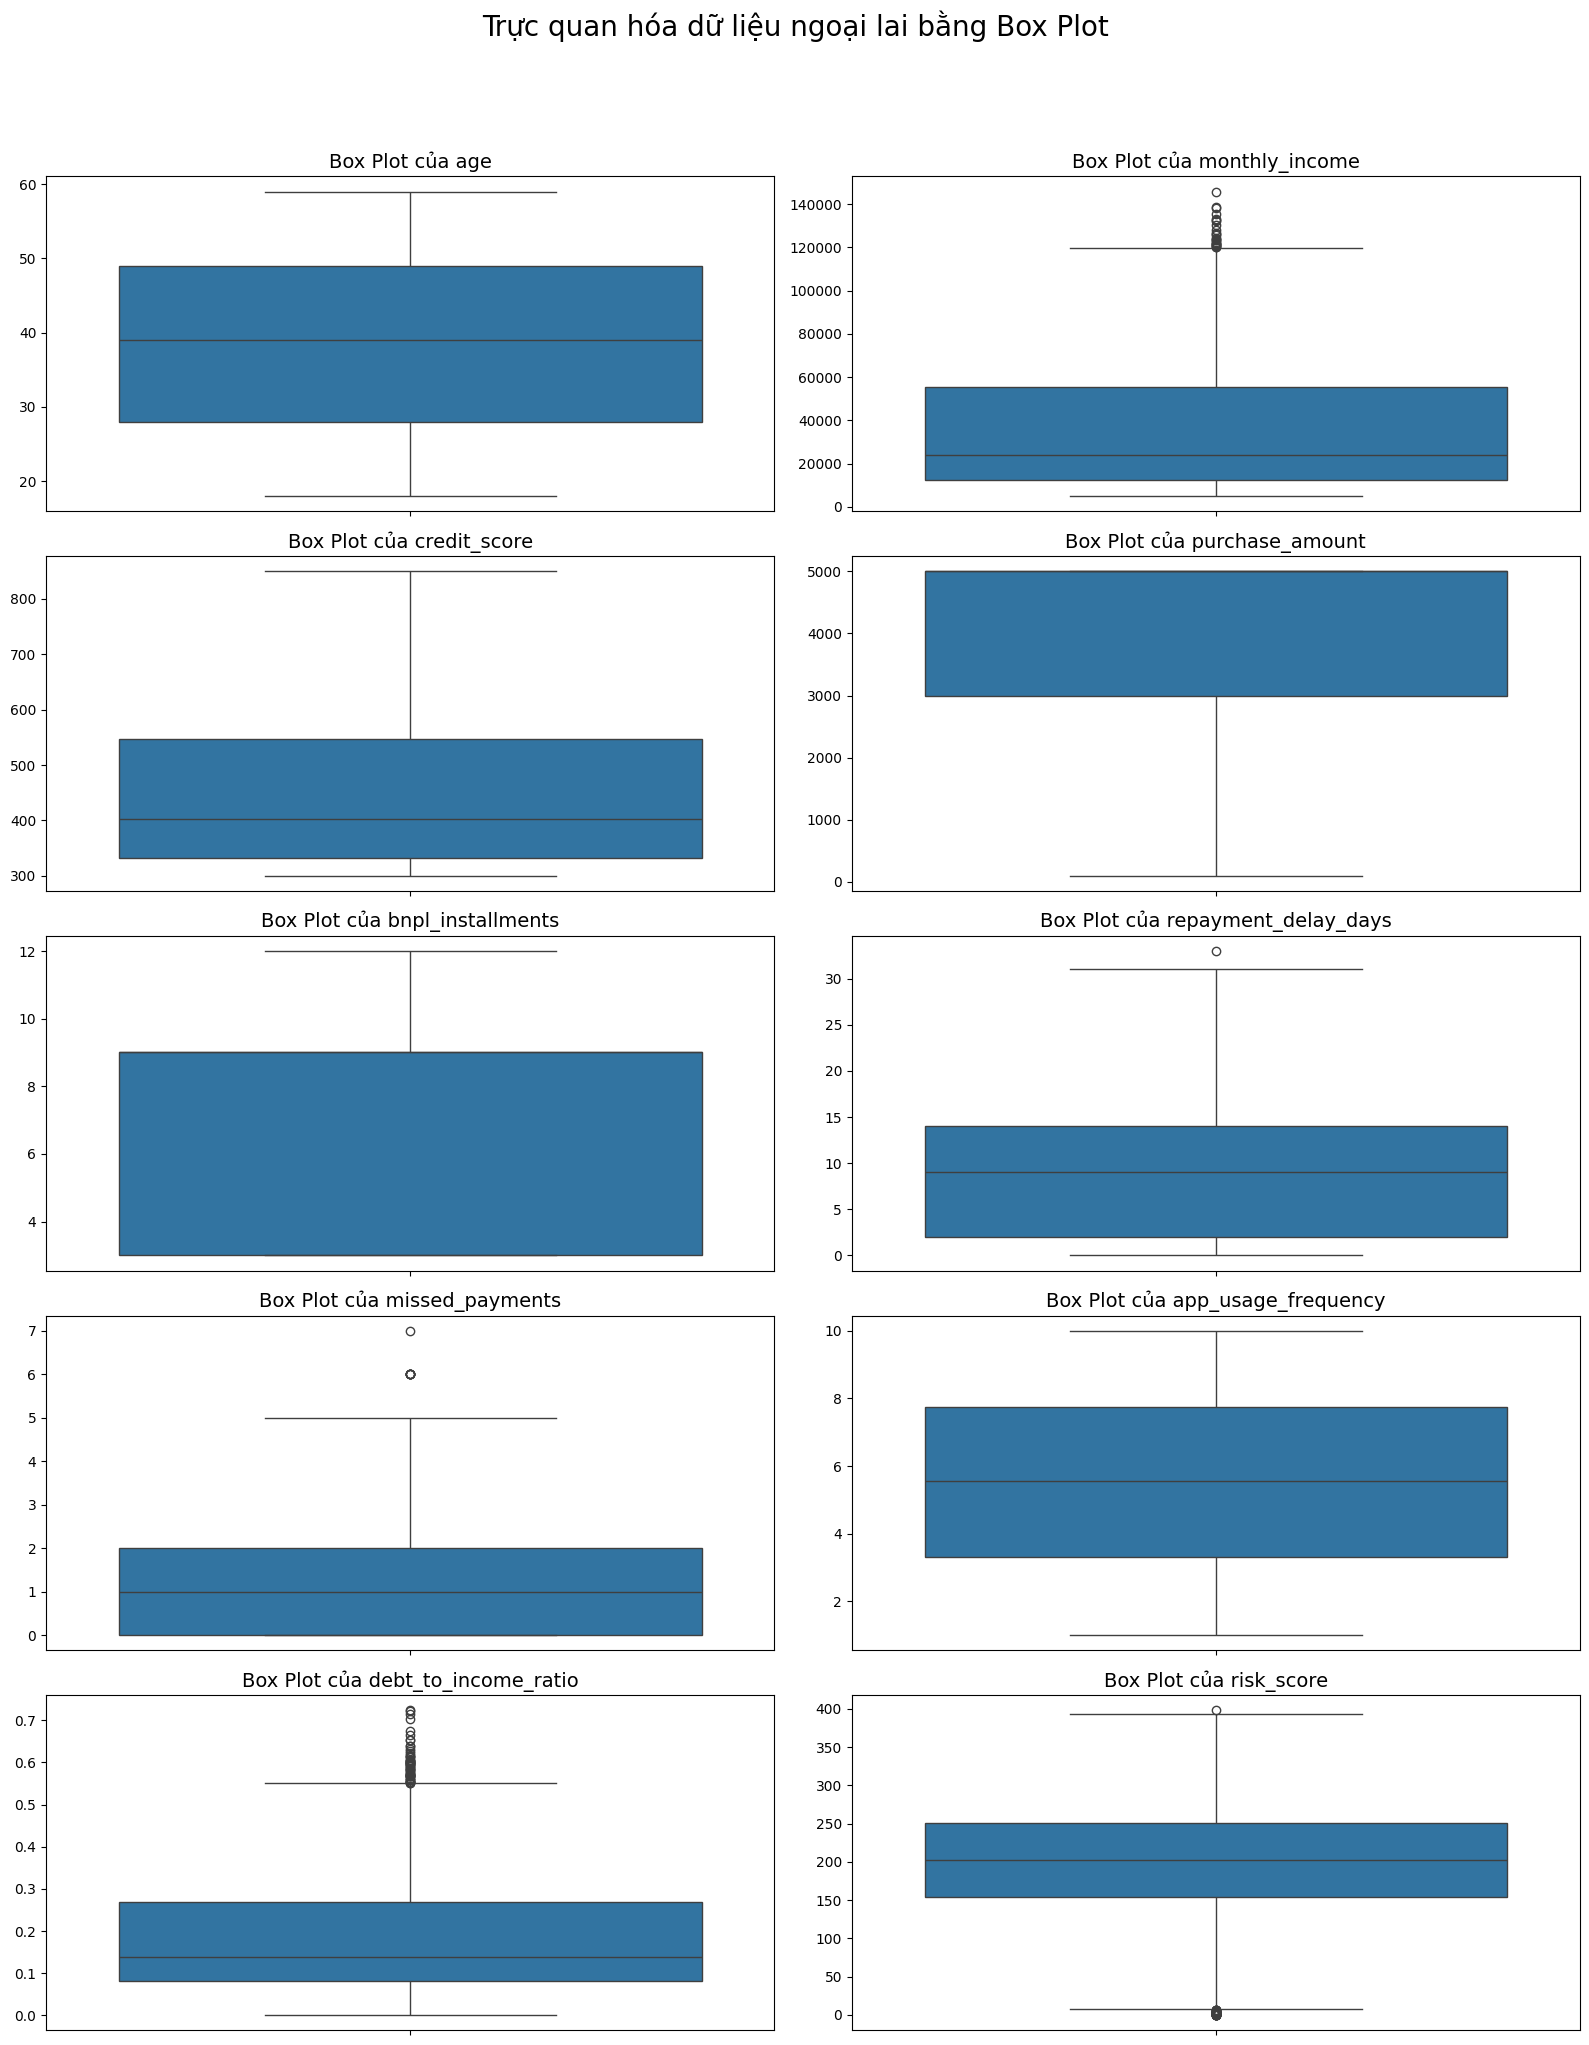

In [ ]:
# ============================================================
# Bước 1: TRỰC QUAN HÓA DỮ LIỆU NGOẠI LAI (OUTLIERS)
# ============================================================

# Xác định các cột số cần kiểm tra ngoại lai
# Loại bỏ 'user_id' (định danh) và 'default_flag' (biến mục tiêu)
numerical_cols = [
    'age',
    'monthly_income',
    'credit_score',
    'purchase_amount',
    'bnpl_installments',
    'repayment_delay_days',
    'missed_payments',
    'app_usage_frequency',
    'debt_to_income_ratio',
    'risk_score'
]

# Tạo biểu đồ hộp cho từng cột số
plt.figure(figsize=(16, 20))
plt.suptitle('Trực quan hóa dữ liệu ngoại lai bằng Box Plot', y=1.02, fontsize=20)

for i, col in enumerate(numerical_cols):
    plt.subplot(5, 2, i + 1) # 5 hàng, 2 cột
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot của {col}', fontsize=14)
    plt.ylabel('') # Bỏ nhãn y để tránh trùng lặp

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('Trực quan hóa outliers.png')
plt.show()

### Nhận xét về kết quả trực quan hóa Outliers:

Các biểu đồ hộp cho thấy sự hiện diện của điểm ngoại lai (outliers) tập trung ở một số tính năng tài chính và rủi ro cốt lõi, cụ thể:

* `monthly_income` & `debt_to_income_ratio`: Xuất hiện lượng lớn điểm ngoại lai ở phía trên đường râu (biên trên), cho thấy sự tồn tại của một nhóm nhỏ khách hàng có thu nhập đột biến và tỷ lệ nợ trên thu nhập (DTI) cao vượt trội so với phần lớn phân phối.

* `missed_payments` & `repayment_delay_days`: Ghi nhận các ngoại lai ở phía trên. Cụ thể có khách hàng lỡ thanh toán tới 6-7 lần hoặc số ngày trễ hạn lên tới hơn 30 ngày. Đây là những chỉ số cảnh báo rủi ro cực kỳ quan trọng cần lọc riêng để xử lý.

* `risk_score`: Xuất hiện một vài điểm ngoại lai ở phía dưới đáy (gần mốc 0), đại diện cho nhóm khách hàng có mức độ an toàn cực kỳ cao.

* Các biến còn lại như `age`, `credit_score`, `purchase_amount`, `bnpl_installments` và `app_usage_frequency` có dải phân bố trải đều và không ghi nhận điểm ngoại lai nằm ngoài phạm vi tính toán của râu biểu đồ (IQR).

**Tính hợp lý của các Outliers và lý do cần xử lý:**

1.  **Tính hợp lý:**
    *   **Trong bối cảnh tài chính, nhiều outliers là hoàn toàn hợp lý và phản ánh đúng thực tế.** Ví dụ, trong `monthly_income` và `purchase_amount`, việc có một số ít khách hàng 'giàu có' hơn hoặc thực hiện các giao dịch lớn là bình thường. `repayment_delay_days` và `missed_payments` cũng sẽ có những giá trị cực đoan đối với những khách hàng thực sự có vấn đề về khả năng thanh toán, những người này chính là nhóm rủi ro cao mà nhóm muốn dự đoán.
    *   Các outliers này thường chứa đựng thông tin quan trọng về các trường hợp đặc biệt, có thể là rủi ro cao hoặc cơ hội lớn, tùy theo ngữ cảnh.

2.  **Tại sao phải xử lý Outliers mặc dù hợp lý:**
    
    Mặc dù các outliers có thể hợp lý về mặt nghiệp vụ, việc xử lý chúng là cần thiết vì những lý do sau, đặc biệt trong bối cảnh xây dựng mô hình dự đoán rủi ro tín dụng:
    *   **Ảnh hưởng đến giả định của mô hình:** Nhiều thuật toán học máy, đặc biệt là các mô hình dựa trên thống kê parametric (ví dụ: hồi quy tuyến tính, Logistic Regression), rất nhạy cảm với outliers. Các giá trị cực đoan có thể làm sai lệch các ước lượng tham số, dẫn đến mô hình không chính xác hoặc kém ổn định.
    *   **Làm sai lệch phân phối:** Outliers làm tăng độ lệch và kéo dài đuôi của phân phối, làm cho dữ liệu không tuân theo các phân phối chuẩn hoặc gần chuẩn, điều mà nhiều thuật toán mong đợi.
    *   **Giảm khả năng khái quát hóa:** Mô hình có thể học quá mức (overfit) trên các điểm ngoại lai, dẫn đến hiệu suất kém khi gặp dữ liệu mới không có các outliers tương tự. Trong dự đoán rủi ro tín dụng, điều này có thể làm giảm khả năng nhận diện chính xác các khách hàng rủi ro.
    *   **Ảnh hưởng đến các thuật toán dựa trên khoảng cách:** Các thuật toán như KNN, SVM, K-Means sử dụng khoảng cách giữa các điểm dữ liệu. Outliers có thể làm sai lệch các tính toán khoảng cách, ảnh hưởng đến việc phân cụm hoặc phân loại.
    *   **Tăng nhiễu (Noise):** Đôi khi, outliers có thể là kết quả của lỗi nhập liệu hoặc lỗi đo lường (mặc dù trong trường hợp này chúng ta giả định chúng là hợp lý). Ngay cả khi hợp lý, chúng vẫn có thể hoạt động như nhiễu nếu chúng quá khác biệt so với phần lớn dữ liệu, làm cho việc học các mẫu cơ bản trở nên khó khăn hơn.

**Các phương pháp xử lý có thể:**

Vì vậy, mặc dù outliers là hợp lý, nhóm vẫn xem xét các chiến lược xử lý để giảm thiểu tác động tiêu cực của chúng lên mô hình. Các phương pháp có thể bao gồm:
*   **Biến đổi dữ liệu:** Các phép biến đổi như logarit (đã áp dụng cho độ lệch) cũng có thể giúp nén các outliers.
*   **Winsorization/Capping:** Giới hạn các giá trị cực đoan ở một ngưỡng nhất định (ví dụ: percentile 1% và 99%).
*   **Loại bỏ (Removal):** Chỉ nên thực hiện một cách rất thận trọng và có lý do vững chắc, vì có thể mất đi thông tin quan trọng.
*   **Các mô hình bền vững (Robust Models)::** Sử dụng các thuật toán ít nhạy cảm với outliers hơn (ví dụ: Tree-based models như Random Forest, XGBoost thường ít bị ảnh hưởng bởi outliers hơn các mô hình tuyến tính). Hoặc sử dụng các phiên bản 'robust' của các thuật toán (ví dụ: Robust Regression).

Trong bài toán dự đoán rủi ro tín dụng, việc quyết định xử lý outliers như thế nào sẽ ảnh hưởng trực tiếp đến khả năng phát hiện các trường hợp vỡ nợ, vì vậy cần phải cân nhắc kỹ lưỡng giữa việc giữ lại thông tin quan trọng và đảm bảo mô hình hoạt động hiệu quả.

In [ ]:
# ============================================================
# Bước 2: XỬ LÝ OUTLIERS — WINSORIZE monthly_income
# ============================================================

# --- 3a. Winsorize monthly_income tại percentile 99% ---
# Lý do: 25 outliers (>119,882) là thu nhập cao thực sự, không phải lỗi.
# Winsorize giữ lại bản ghi nhưng cap giá trị cực đoan để biểu đồ cân đối hơn.
p99 = df["monthly_income"].quantile(0.99)
df["monthly_income_capped"] = df["monthly_income"].clip(upper=p99)

n_capped = (df["monthly_income"] > p99).sum()
print(f"  [3a] monthly_income — Winsorize tại Percentile 99%")
print(f"       Ngưỡng cap (p99)     : {p99:,.2f}")
print(f"       Số giá trị được cap  : {n_capped} records")
print(f"       Giá trị max trước cap: {df['monthly_income'].max():,.2f}")
print(f"       Giá trị max sau cap  : {df['monthly_income_capped'].max():,.2f}")
print(f"       → Tạo cột mới        : 'monthly_income_capped'")

# --- 3b. Các outliers khác — GIỮ NGUYÊN ---
print(f"\n  [3b] Các biến khác — Giữ nguyên (lý do nghiệp vụ)")
print(f"       • debt_to_income_ratio : 57 outliers → nhóm rủi ro cao thực sự")
print(f"         (default rate 47.4% vs. trung bình 39.1% — có giá trị insight)")
print(f"       • missed_payments      : 8 outliers (giá trị 6-7) → tất cả default=1")
print(f"       • repayment_delay_days : 1 outlier (33 ngày) → chênh lệch 1 ngày")
print(f"       • risk_score           : 31 outliers → hợp lệ về nghiệp vụ")

  [3a] monthly_income — Winsorize tại Percentile 99%
       Ngưỡng cap (p99)     : 104,659.98
       Số giá trị được cap  : 104 records
       Giá trị max trước cap: 145,767.12
       Giá trị max sau cap  : 104,659.98
       → Tạo cột mới        : 'monthly_income_capped'

  [3b] Các biến khác — Giữ nguyên (lý do nghiệp vụ)
       • debt_to_income_ratio : 57 outliers → nhóm rủi ro cao thực sự
         (default rate 47.4% vs. trung bình 39.1% — có giá trị insight)
       • missed_payments      : 8 outliers (giá trị 6-7) → tất cả default=1
       • repayment_delay_days : 1 outlier (33 ngày) → chênh lệch 1 ngày
       • risk_score           : 31 outliers → hợp lệ về nghiệp vụ


**Giải thích lý do chỉ xử lý Outliers cho `monthly_income` và lựa chọn phương pháp Winsorization:**

1.  **Lý do chỉ xử lý `monthly_income` (và không xử lý các cột khác):**
    *   **`monthly_income`:** Mặc dù các giá trị thu nhập rất cao là hợp lý, nhưng dải giá trị quá rộng của chúng có thể tạo ra ảnh hưởng không cân đối lên các mô hình học máy, đặc biệt là các mô hình dựa trên khoảng cách hoặc độ dốc (gradient-based). Việc có một số ít khách hàng có thu nhập cực cao có thể làm **sai lệch đáng kể trung bình và độ lệch chuẩn**, khiến các mô hình gặp khó khăn trong việc học mối quan hệ giữa thu nhập và rủi ro một cách hiệu quả trên toàn bộ phổ dữ liệu. Việc nén các giá trị này giúp phân phối thu nhập trở nên cân bằng hơn, giảm thiểu tác động tiêu cực của các giá trị cực đoan mà không làm mất đi thông tin về thứ hạng tương đối.
    *   **Các cột khác (`debt_to_income_ratio`, `missed_payments`, `repayment_delay_days`, `risk_score`):** Các outliers trong các cột này (như DTI cao, số lần bỏ lỡ thanh toán nhiều, số ngày trễ hạn lớn, điểm rủi ro cao) thường là **dấu hiệu trực tiếp và mạnh mẽ của rủi ro tín dụng cao**. Nếu loại bỏ hoặc Winsorize quá mức các giá trị này, chúng ta có thể **làm mất đi những tín hiệu quan trọng nhất** mà mô hình cần học để phân biệt giữa khách hàng an toàn và khách hàng rủi ro. Việc giữ nguyên các outliers này giúp mô hình nhận diện chính xác các trường hợp cực đoan, vốn là trọng tâm của bài toán dự đoán rủi ro tín dụng. Ví dụ, một khách hàng có 6 lần bỏ lỡ thanh toán là một outlier so với phần lớn khách hàng, nhưng đây là thông tin quý giá cho thấy rủi ro rất cao.

2.  **Lý do lựa chọn Winsorization cho `monthly_income`:**
    *   **Giữ lại dữ liệu:** Winsorization (capping) là phương pháp tốt hơn so với loại bỏ (deletion) outliers, đặc biệt khi các outliers là hợp lý và chứa thông tin. Nó cho phép chúng ta giữ lại toàn bộ số lượng bản ghi trong tập dữ liệu, tránh làm giảm kích thước mẫu và mất mát thông tin tiềm ẩn.
    *   **Giảm thiểu tác động của các giá trị cực đoan:** Bằng cách giới hạn các giá trị nằm ngoài một ngưỡng nhất định (ví dụ: percentile 99%), Winsorization giúp 'nén' các giá trị cực đoan lại gần với phần còn lại của phân phối mà không thay đổi thứ hạng của chúng. Điều này làm cho phân phối trở nên ít lệch hơn, giảm thiểu ảnh hưởng của các giá trị này lên mean, variance, và các mối tương quan, giúp các mô hình học máy hoạt động ổn định và chính xác hơn.
    *   **Phù hợp với mục tiêu mô hình:** Trong bài toán rủi ro tín dụng, việc một người có thu nhập cao đến một mức độ nào đó là đủ để đánh giá khả năng trả nợ. Thu nhập quá cao (ví dụ, cao hơn percentile 99%) có thể không mang lại nhiều thông tin dự đoán rủi ro tăng thêm mà chỉ làm cho dữ liệu bị kéo giãn. Winsorization giúp tập trung vào dải thu nhập có ý nghĩa dự đoán cao hơn mà không bỏ qua khách hàng có thu nhập rất cao.

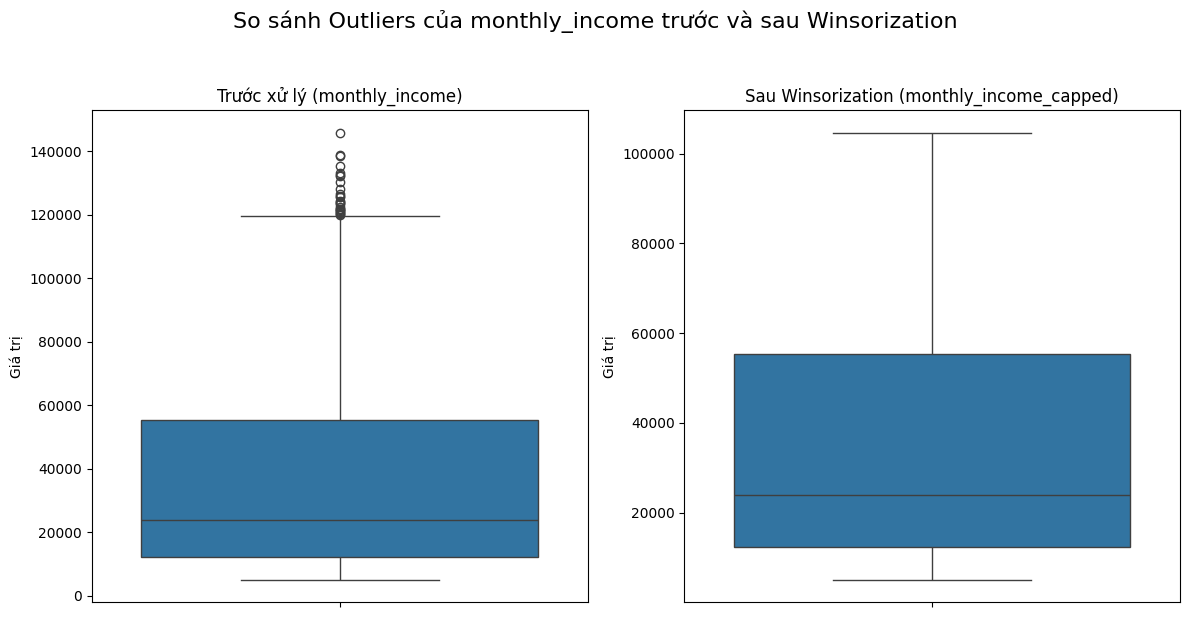

In [ ]:
# ============================================================
# Bước 3: SO SÁNH TÌNH TRẠNG OUTLIERS TRƯỚC VÀ SAU KHI XỬ LÝ
# ============================================================

# Cột gốc và cột đã được xử lý
col_original = "monthly_income"
col_processed = "monthly_income_capped"

plt.figure(figsize=(12, 6))
plt.suptitle(f'So sánh Outliers của {col_original} trước và sau Winsorization', y=1.02, fontsize=16)

# Box plot cho dữ liệu gốc
plt.subplot(1, 2, 1)
sns.boxplot(y=df[col_original])
plt.title(f'Trước xử lý ({col_original})')
plt.ylabel('Giá trị')

# Box plot cho dữ liệu đã được xử lý (Winsorized)
plt.subplot(1, 2, 2)
sns.boxplot(y=df[col_processed])
plt.title(f'Sau Winsorization ({col_processed})')
plt.ylabel('Giá trị')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('So sánh Outliers monthly_income.png')
plt.show()

**Nhận xét tình trạng Outliers của `monthly_income` sau khi xử lý:**

Biểu đồ hộp đã cho thấy rõ hiệu quả của phương pháp Winsorization đối với cột `monthly_income`.

*   **Trước khi xử lý:** Cột `monthly_income` hiển thị nhiều điểm ngoại lai ở phía trên, kéo dài đáng kể ra khỏi phần thân chính của dữ liệu, cho thấy sự hiện diện của một số ít giá trị thu nhập rất cao.
*   **Sau khi áp dụng Winsorization:** Cột `monthly_income_capped` đã có các giá trị ngoại lai được giới hạn lại ở ngưỡng 99th percentile. Điều này giúp 'nén' các giá trị cực đoan lại gần với phần còn lại của phân phối mà không loại bỏ chúng.

Kết quả là, biểu đồ hộp của `monthly_income_capped` trở nên cân đối hơn, với các 'râu' (whiskers) được rút ngắn đáng kể, chứng tỏ phương pháp Winsorization đã thành công trong việc giảm thiểu tác động của các giá trị cực đoan mà vẫn giữ lại thông tin quan trọng. Điều này sẽ giúp các mô hình học máy hoạt động ổn định và chính xác hơn.

In [ ]:
# ============================================================
# KIỂM TRA KẾT QUẢ CUỐI
# ============================================================

new_cols = ["monthly_income_log", "dti_sqrt", "monthly_income_capped"]
print(f" Shape sau xử lý : {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"  Cột mới thêm vào: {new_cols}")

# Kiểm tra không có giá trị NaN mới phát sinh
nan_check = df[new_cols].isnull().sum()
if nan_check.sum() == 0:
    print(f"\n  ✓ Không có NaN phát sinh sau transform.")
else:
    print(f"\n  ✗ Cảnh báo — NaN phát sinh:")
    print(nan_check[nan_check > 0])

 Shape sau xử lý : 10,345 dòng × 20 cột
  Cột mới thêm vào: ['monthly_income_log', 'dti_sqrt', 'monthly_income_capped']

  ✓ Không có NaN phát sinh sau transform.


In [ ]:
# ============================================================
# XUẤT FILE CSV
# ============================================================

df.to_csv('BNPL_cleaned.csv', index=False, encoding="utf-8-sig")

print("✓ Đã xuất: BNPL_cleaned.csv")
print(f"  → {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"  → Encoding: UTF-8 with BOM (mở được bằng Excel)")

✓ Đã xuất: BNPL_cleaned.csv
  → 10,345 dòng × 20 cột
  → Encoding: UTF-8 with BOM (mở được bằng Excel)


------------------------------------------
# 3. Thống kê và trực quan hóa (EDA)

## 3.0. Cấu hình và Chuẩn bị

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# --- Cấu hình chung ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 120,
})

# Màu sắc nhất quán xuyên suốt
COLOR_SAFE    = "#2196F3"   # Xanh dương → Không vỡ nợ (default_flag = 0)
COLOR_DEFAULT = "#F44336"   # Đỏ         → Vỡ nợ       (default_flag = 1)
PALETTE_2     = [COLOR_SAFE, COLOR_DEFAULT]

# --- Load dữ liệu & tái tạo các cột transform từ bước tiền xử lý ---
df = pd.read_csv('Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv')

df["monthly_income_log"]    = np.log1p(df["monthly_income"])
df["dti_sqrt"]              = np.sqrt(df["debt_to_income_ratio"])
p99 = df["monthly_income"].quantile(0.99)
df["monthly_income_capped"] = df["monthly_income"].clip(upper=p99)

df_safe    = df[df["default_flag"] == 0]
df_default = df[df["default_flag"] == 1]

print(f"✓ Dữ liệu sẵn sàng: {df.shape[0]:,} quan sát × {df.shape[1]} cột")
print(f"  • Không vỡ nợ (0): {len(df_safe):,}  ({len(df_safe)/len(df)*100:.1f}%)")
print(f"  • Vỡ nợ (1)      : {len(df_default):,}  ({len(df_default)/len(df)*100:.1f}%)")


✓ Dữ liệu sẵn sàng: 10,345 quan sát × 20 cột
  • Không vỡ nợ (0): 6,305  (60.9%)
  • Vỡ nợ (1)      : 4,040  (39.1%)


## 3.1. Hành vi thanh toán trong quá khứ và nguy cơ vỡ nợ

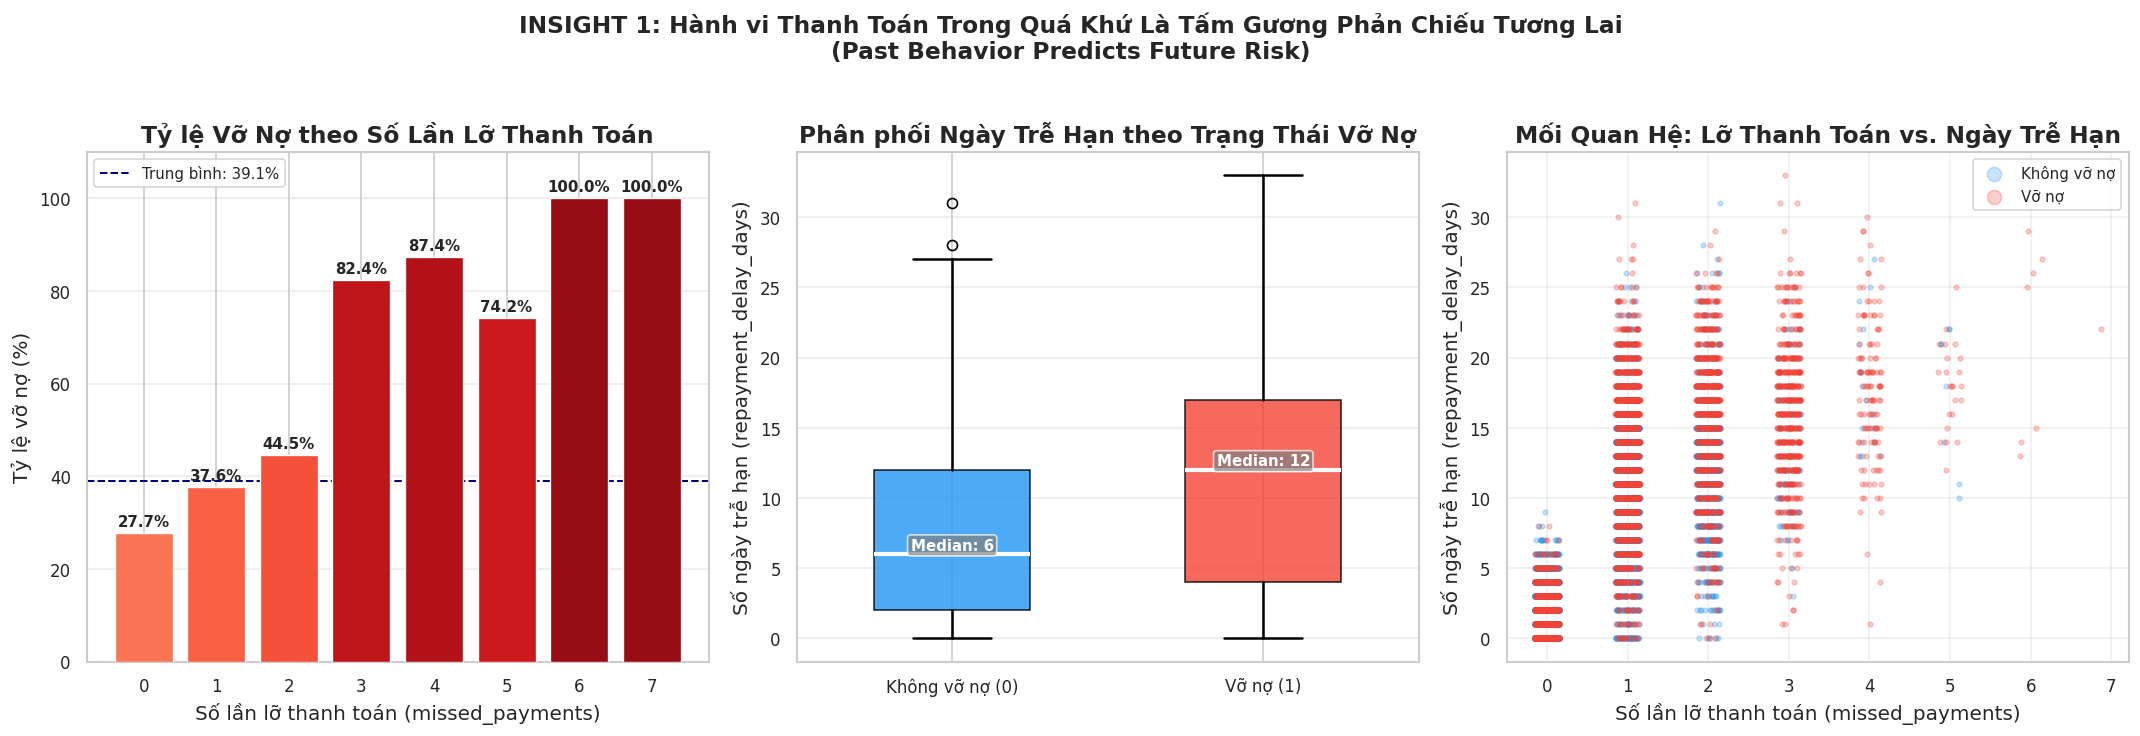

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "INSIGHT 1: Hành vi Thanh Toán Trong Quá Khứ Là Tấm Gương Phản Chiếu Tương Lai\n"
    "(Past Behavior Predicts Future Risk)",
    fontsize=14, fontweight="bold", y=1.02
)

# --- 1a. Tỷ lệ vỡ nợ theo số lần lỡ thanh toán ---
ax = axes[0]
mp_rate = (df.groupby("missed_payments")["default_flag"]
             .mean().reset_index()
             .rename(columns={"default_flag": "default_rate"}))

bars = ax.bar(mp_rate["missed_payments"], mp_rate["default_rate"] * 100,
              color=[plt.cm.Reds(0.3 + v * 0.6) for v in mp_rate["default_rate"]],
              edgecolor="white", linewidth=0.8, zorder=3)
for bar, rate in zip(bars, mp_rate["default_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{rate*100:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(df["default_flag"].mean()*100, color="navy", linestyle="--",
           linewidth=1.2, label=f"Trung bình: {df['default_flag'].mean()*100:.1f}%")
ax.set_xlabel("Số lần lỡ thanh toán (missed_payments)")
ax.set_ylabel("Tỷ lệ vỡ nợ (%)")
ax.set_title("Tỷ lệ Vỡ Nợ theo Số Lần Lỡ Thanh Toán", fontweight="bold")
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.4)

# --- 1b. Boxplot ngày trễ hạn theo default_flag ---
ax = axes[1]
data_plot = [df_safe["repayment_delay_days"], df_default["repayment_delay_days"]]
bp = ax.boxplot(data_plot, patch_artist=True, widths=0.5,
                medianprops=dict(color="white", linewidth=2.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))
for patch, color in zip(bp["boxes"], PALETTE_2):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_xticklabels(["Không vỡ nợ (0)", "Vỡ nợ (1)"])
ax.set_ylabel("Số ngày trễ hạn (repayment_delay_days)")
ax.set_title("Phân phối Ngày Trễ Hạn theo Trạng Thái Vỡ Nợ", fontweight="bold")
for i, data in enumerate(data_plot, 1):
    med = np.median(data)
    ax.text(i, med + 0.3, f"Median: {med:.0f}", ha="center", fontsize=9,
            fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.2", fc="gray", alpha=0.7))
ax.grid(axis="y", alpha=0.4)

# --- 1c. Scatter: missed_payments vs repayment_delay_days ---
ax = axes[2]
for flag, color, label in [(0, COLOR_SAFE, "Không vỡ nợ"), (1, COLOR_DEFAULT, "Vỡ nợ")]:
    subset = df[df["default_flag"] == flag]
    ax.scatter(subset["missed_payments"] + np.random.uniform(-0.15, 0.15, len(subset)),
               subset["repayment_delay_days"],
               c=color, alpha=0.25, s=8, label=label)
ax.set_xlabel("Số lần lỡ thanh toán (missed_payments)")
ax.set_ylabel("Số ngày trễ hạn (repayment_delay_days)")
ax.set_title("Mối Quan Hệ: Lỡ Thanh Toán vs. Ngày Trễ Hạn", fontweight="bold")
ax.legend(markerscale=3, fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("insight1_hanh_vi_thanh_toan.png", bbox_inches="tight", dpi=150)
plt.show()


### Giải thích Insight 1

Kết quả trực quan hóa khẳng định một trong những nguyên lý vàng của quản trị rủi ro tín dụng: **hành vi thanh toán trong quá khứ là tín hiệu dự báo mạnh nhất cho tương lai**.

**Biểu đồ 1 (Tỷ lệ vỡ nợ theo số lần lỡ thanh toán):** Tồn tại một mối quan hệ đơn điệu tăng rõ ràng. Khách hàng không có lần lỡ thanh toán nào có tỷ lệ vỡ nợ chỉ xấp xỉ trung bình chung (~39%), trong khi những khách hàng có từ 3–5 lần lỡ thanh toán có tỷ lệ vỡ nợ leo thang đáng kể. Điều này phản ánh **hiệu ứng "lăn cầu tuyết" (snowball effect)**: một khi đã lỡ thanh toán, phí phạt và áp lực dòng tiền cộng dồn, khiến người vay ngày càng khó thoát khỏi vòng nợ.

**Biểu đồ 2 (Boxplot ngày trễ hạn):** Nhóm vỡ nợ có trung vị số ngày trễ hạn cao hơn hẳn nhóm an toàn, đồng thời phân phối cũng rộng hơn (đuôi trên dài hơn), cho thấy **sự phân tầng rủi ro theo mức độ trễ hạn** là có căn cứ thống kê. Nhóm an toàn tập trung rất chặt ở mức trễ thấp.

**Biểu đồ 3 (Scatter):** Cụm màu đỏ (vỡ nợ) có xu hướng tập trung ở góc phần tư trên-phải của đồ thị — tức là vừa có số lần lỡ thanh toán nhiều vừa có số ngày trễ hạn lớn. Điều này xác nhận rằng **hai biến `missed_payments` và `repayment_delay_days` có tác động cộng hưởng** đến xác suất vỡ nợ, không phải độc lập.

**Khuyến nghị nghiệp vụ:** Cần thiết lập **hệ thống cảnh báo sớm tự động (Early Warning System)**. Ngay khi `repayment_delay_days > 3` hoặc `missed_payments ≥ 1`, hệ thống nên khóa việc cấp hạn mức mới và chủ động liên hệ nhắc nhở khách hàng.


---
## 3.2. Insight 2: Sức Ép Từ Đòn Bẩy Tài Chính Cá Nhân (DTI)
**Biến phân tích:** `debt_to_income_ratio` (Tỷ lệ Nợ trên Thu nhập — DTI)


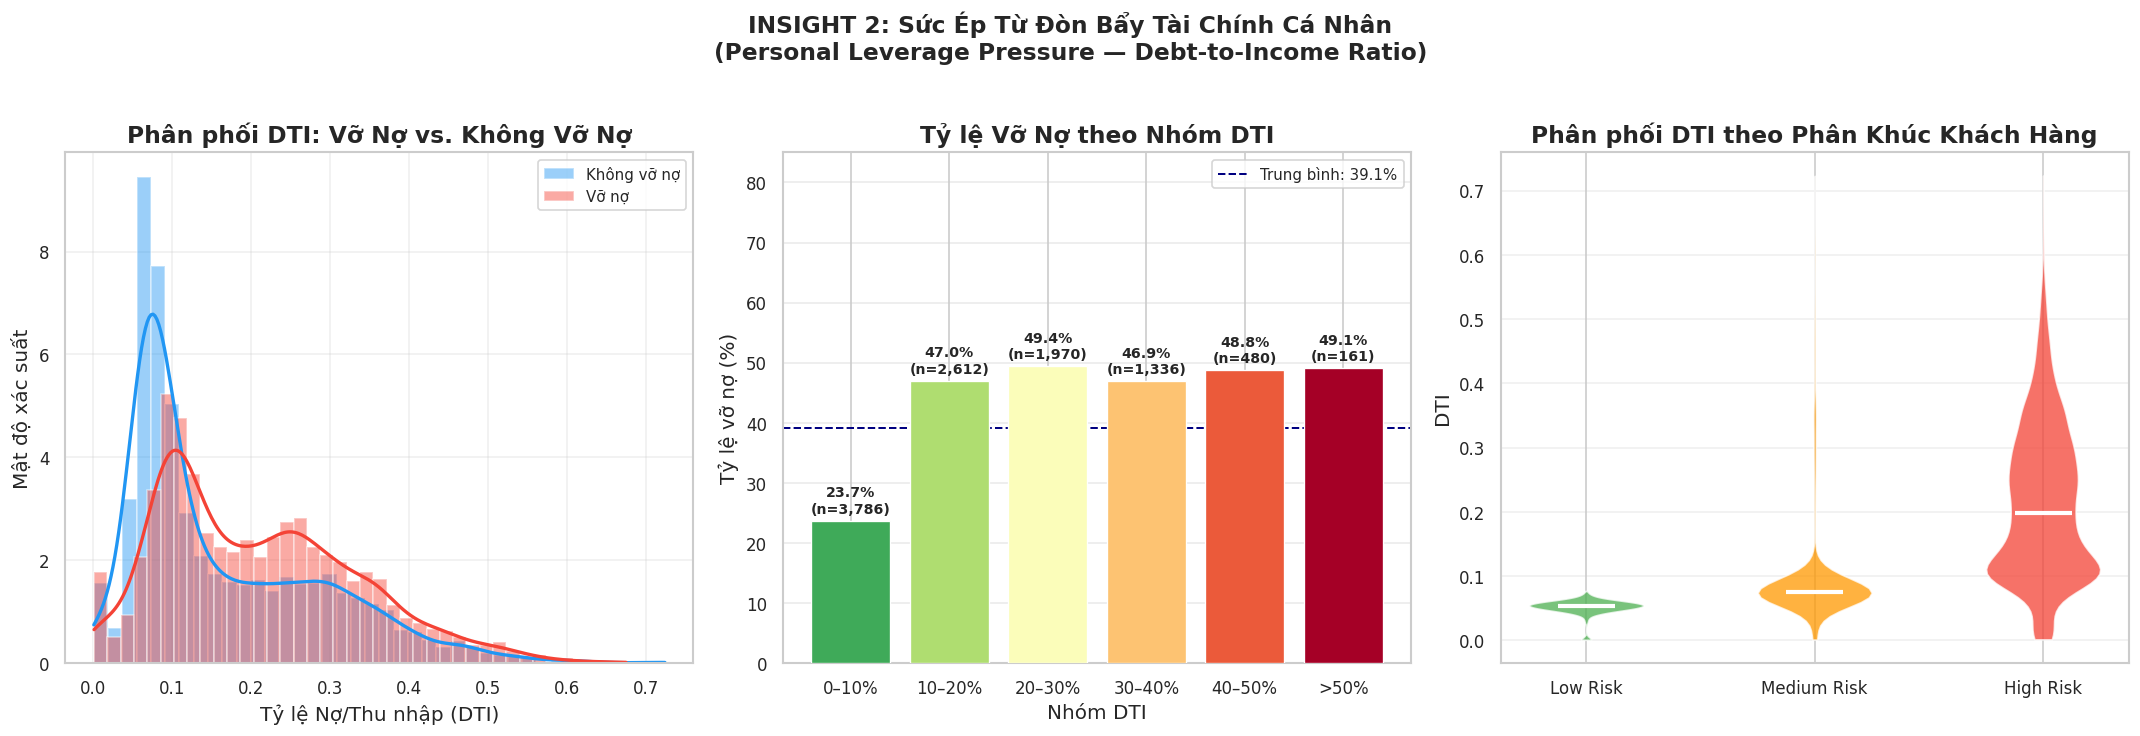

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "INSIGHT 2: Sức Ép Từ Đòn Bẩy Tài Chính Cá Nhân\n"
    "(Personal Leverage Pressure — Debt-to-Income Ratio)",
    fontsize=14, fontweight="bold", y=1.02
)

# --- 2a. Phân phối DTI theo default_flag (KDE) ---
ax = axes[0]
for flag, color, label in [(0, COLOR_SAFE, "Không vỡ nợ"), (1, COLOR_DEFAULT, "Vỡ nợ")]:
    subset = df[df["default_flag"] == flag]["debt_to_income_ratio"]
    ax.hist(subset, bins=40, alpha=0.45, color=color, density=True, label=label)
    kde_x = np.linspace(subset.min(), subset.max(), 300)
    ax.plot(kde_x, stats.gaussian_kde(subset)(kde_x), color=color, linewidth=2)
ax.set_xlabel("Tỷ lệ Nợ/Thu nhập (DTI)")
ax.set_ylabel("Mật độ xác suất")
ax.set_title("Phân phối DTI: Vỡ Nợ vs. Không Vỡ Nợ", fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# --- 2b. Tỷ lệ vỡ nợ theo nhóm DTI ---
ax = axes[1]
bins   = [0, 0.10, 0.20, 0.30, 0.40, 0.50, 1.0]
labels = ["0–10%", "10–20%", "20–30%", "30–40%", "40–50%", ">50%"]
df["dti_group"] = pd.cut(df["debt_to_income_ratio"], bins=bins, labels=labels)
dti_summary = (df.groupby("dti_group", observed=True)["default_flag"]
                 .agg(["mean","count"]).reset_index()
                 .rename(columns={"mean":"default_rate","count":"n"}))
colors_bar = [plt.cm.RdYlGn_r(0.15 + i*0.17) for i in range(len(dti_summary))]
bars = ax.bar(dti_summary["dti_group"], dti_summary["default_rate"]*100,
              color=colors_bar, edgecolor="white", linewidth=0.8, zorder=3)
for bar, row in zip(bars, dti_summary.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{row.default_rate*100:.1f}%\n(n={row.n:,})",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold")
ax.axhline(df["default_flag"].mean()*100, color="navy", linestyle="--",
           linewidth=1.2, label=f"Trung bình: {df['default_flag'].mean()*100:.1f}%")
ax.set_xlabel("Nhóm DTI"); ax.set_ylabel("Tỷ lệ vỡ nợ (%)")
ax.set_title("Tỷ lệ Vỡ Nợ theo Nhóm DTI", fontweight="bold")
ax.set_ylim(0, 85); ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.4)

# --- 2c. Violin plot DTI theo customer_segment ---
ax = axes[2]
seg_order  = ["Low Risk", "Medium Risk", "High Risk"]
seg_colors = ["#4CAF50", "#FF9800", "#F44336"]
vp = ax.violinplot(
    [df[df["customer_segment"]==seg]["debt_to_income_ratio"].dropna() for seg in seg_order],
    positions=[1,2,3], showmedians=True, showextrema=False)
for body, color in zip(vp["bodies"], seg_colors):
    body.set_facecolor(color); body.set_alpha(0.75)
vp["cmedians"].set_color("white"); vp["cmedians"].set_linewidth(2.5)
ax.set_xticks([1,2,3]); ax.set_xticklabels(seg_order)
ax.set_ylabel("DTI"); ax.set_title("Phân phối DTI theo Phân Khúc Khách Hàng", fontweight="bold")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("insight2_don_bay_tai_chinh.png", bbox_inches="tight", dpi=150)
plt.show()


### Giải thích Insight 2

DTI là **thước đo trực tiếp nhất về gánh nặng tài chính** của một cá nhân và đây là insight quan trọng bậc nhất với các mô hình BNPL.

**Biểu đồ 1 (KDE phân phối DTI):** Đường cong mật độ của nhóm vỡ nợ (màu đỏ) dịch chuyển hẳn về phía phải so với nhóm an toàn (màu xanh), nghĩa là nhóm vỡ nợ có DTI cao hơn một cách hệ thống. Sự tách biệt này cho thấy DTI có **sức mạnh phân loại tốt** giữa hai nhóm.

**Biểu đồ 2 (Tỷ lệ vỡ nợ theo nhóm DTI):** Kết quả cho thấy xu hướng tăng rõ ràng. Đặc biệt đáng chú ý là ngưỡng **DTI > 30–40%** — vốn được coi là ngưỡng an toàn trong ngành tài chính truyền thống — vẫn chứng kiến tỷ lệ vỡ nợ tăng vọt trong bối cảnh BNPL. Điều này khẳng định **ảo giác sức mua** mà BNPL tạo ra: chia nhỏ khoản nợ che giấu tổng gánh nặng thực sự của người vay.

**Biểu đồ 3 (Violin plot theo phân khúc):** Nhóm `High Risk` có phân phối DTI rộng và lệch hẳn lên cao so với `Low Risk`. Điều thú vị là sự chênh lệch giữa `Medium Risk` và `High Risk` khá lớn, cho thấy DTI là một yếu tố phân tầng hiệu quả trong hệ thống phân loại rủi ro.

**Khuyến nghị nghiệp vụ:** Điểm rủi ro nội bộ (`risk_score`) phải gán **trọng số cực kỳ cao cho biến DTI**. Cần thiết lập hạn mức tín dụng tối đa tỷ lệ nghịch với DTI của khách hàng, đồng thời từ chối tự động các đơn vay khi DTI dự phóng (sau khoản vay mới) vượt 40%.


---
## 3.3. Insight 3: Tính Ổn Định Dòng Tiền Quan Trọng Hơn Mức Thu Nhập Tuyệt Đối
**Biến phân tích:** `employment_type` (Loại hình việc làm), `monthly_income` (Thu nhập hàng tháng)


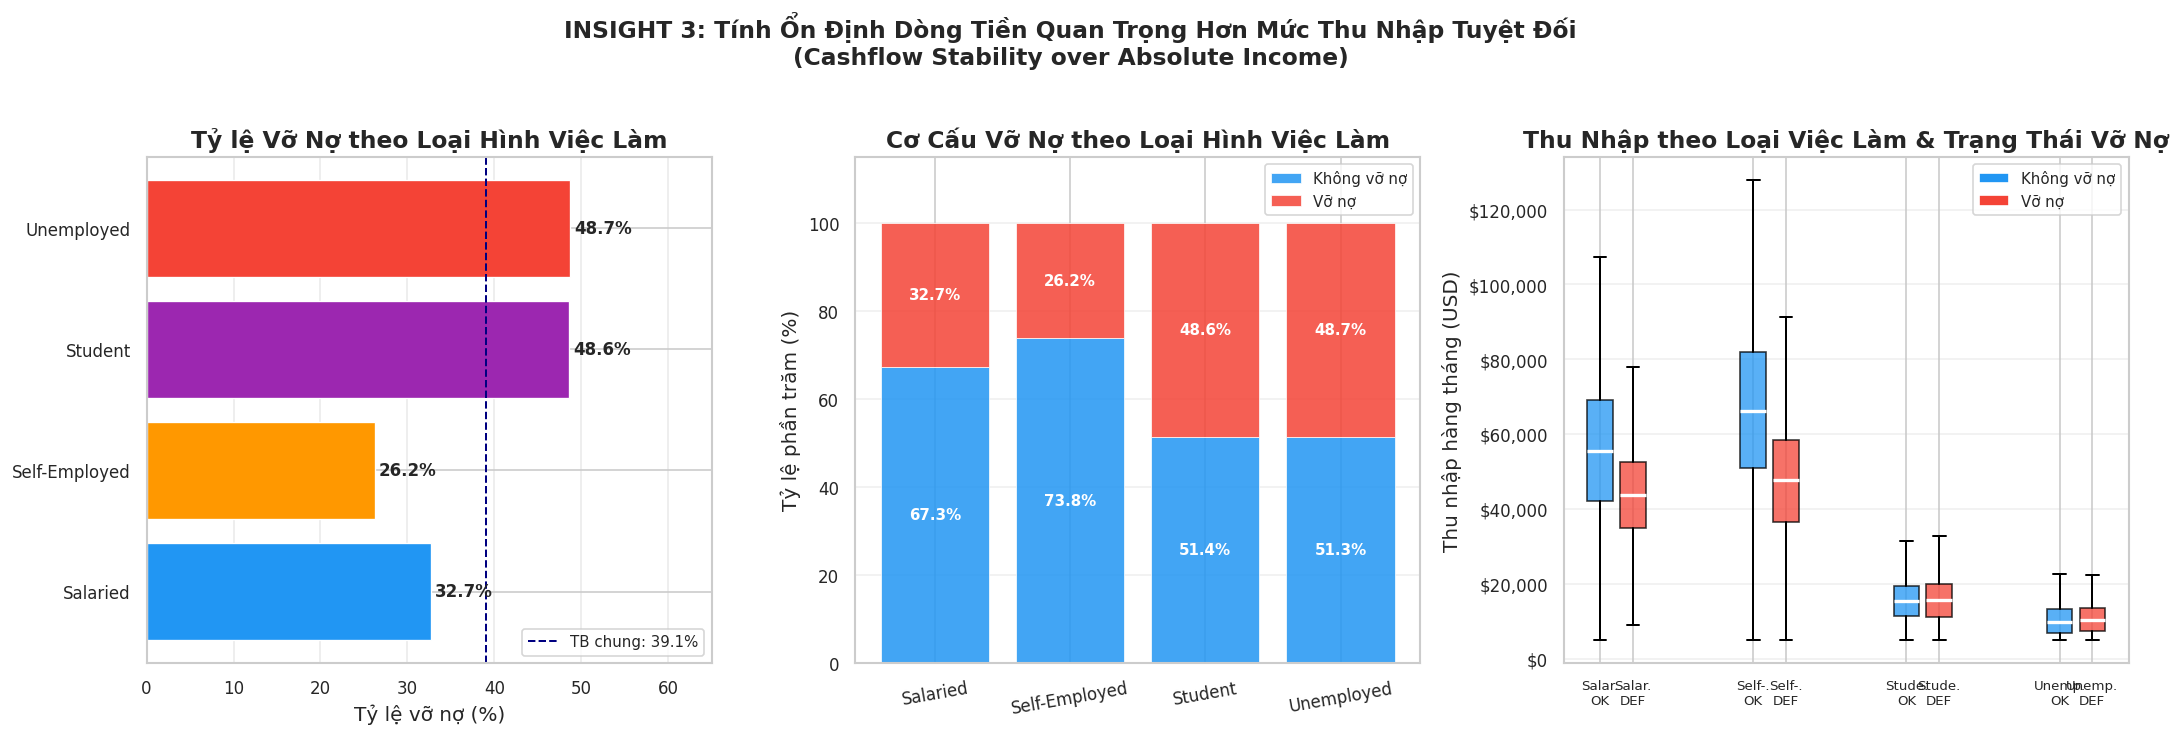

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "INSIGHT 3: Tính Ổn Định Dòng Tiền Quan Trọng Hơn Mức Thu Nhập Tuyệt Đối\n"
    "(Cashflow Stability over Absolute Income)",
    fontsize=14, fontweight="bold", y=1.02
)

emp_order  = ["Salaried", "Self-Employed", "Student", "Unemployed"]
emp_colors = {"Salaried":"#2196F3","Self-Employed":"#FF9800","Student":"#9C27B0","Unemployed":"#F44336"}

# --- 3a. Tỷ lệ vỡ nợ theo loại hình việc làm ---
ax = axes[0]
emp_default = (df.groupby("employment_type")["default_flag"]
                 .mean().reindex(emp_order).reset_index()
                 .rename(columns={"default_flag":"default_rate"}))
bars = ax.barh(emp_default["employment_type"], emp_default["default_rate"]*100,
               color=[emp_colors[e] for e in emp_default["employment_type"]],
               edgecolor="white", linewidth=0.8)
for bar, rate in zip(bars, emp_default["default_rate"]):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f"{rate*100:.1f}%", va="center", fontsize=10, fontweight="bold")
ax.axvline(df["default_flag"].mean()*100, color="navy", linestyle="--",
           linewidth=1.2, label=f"TB chung: {df['default_flag'].mean()*100:.1f}%")
ax.set_xlabel("Tỷ lệ vỡ nợ (%)"); ax.set_xlim(0, 65)
ax.set_title("Tỷ lệ Vỡ Nợ theo Loại Hình Việc Làm", fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0.4)

# --- 3b. Stacked bar: cơ cấu Safe vs Default ---
ax = axes[1]
emp_cross = df.groupby(["employment_type","default_flag"]).size().unstack(fill_value=0).reindex(emp_order)
emp_pct   = emp_cross.div(emp_cross.sum(axis=1), axis=0)*100
bottom = np.zeros(len(emp_order))
for flag, color, label in [(0,COLOR_SAFE,"Không vỡ nợ"),(1,COLOR_DEFAULT,"Vỡ nợ")]:
    vals = emp_pct[flag].values
    bars = ax.bar(emp_order, vals, bottom=bottom, color=color, alpha=0.85,
                  label=label, edgecolor="white", linewidth=0.5)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 5:
            ax.text(bar.get_x()+bar.get_width()/2, bot+val/2, f"{val:.1f}%",
                    ha="center", va="center", fontsize=9, fontweight="bold", color="white")
    bottom += vals
ax.set_ylabel("Tỷ lệ phần trăm (%)"); ax.set_ylim(0,115)
ax.set_title("Cơ Cấu Vỡ Nợ theo Loại Hình Việc Làm", fontweight="bold")
ax.legend(loc="upper right", fontsize=9); ax.tick_params(axis="x", rotation=10)
ax.grid(axis="y", alpha=0.3)

# --- 3c. Boxplot thu nhập theo employment_type & default_flag ---
ax = axes[2]
from matplotlib.patches import Patch
plot_data, positions, colors_box = [], [], []
pos = 1; gap = 0.45; group_gap = 1.2
for emp in emp_order:
    for flag, color in [(0,COLOR_SAFE),(1,COLOR_DEFAULT)]:
        plot_data.append(df[(df["employment_type"]==emp)&(df["default_flag"]==flag)]["monthly_income"])
        colors_box.append(color); positions.append(pos); pos += gap
    pos += group_gap
bp = ax.boxplot(plot_data, positions=positions, patch_artist=True,
                widths=0.35, showfliers=False,
                medianprops=dict(color="white", linewidth=2),
                whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2))
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color); patch.set_alpha(0.75)
tick_labels = [f"{e[:5]}.\n{'OK' if f==0 else 'DEF'}" for e in emp_order for f in [0,1]]
ax.set_xticks(positions); ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_ylabel("Thu nhập hàng tháng (USD)")
ax.set_title("Thu Nhập theo Loại Việc Làm & Trạng Thái Vỡ Nợ", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.legend(handles=[Patch(facecolor=COLOR_SAFE,label="Không vỡ nợ"),
                   Patch(facecolor=COLOR_DEFAULT,label="Vỡ nợ")], fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("insight3_on_dinh_dong_tien.png", bbox_inches="tight", dpi=150)
plt.show()


### Giải thích Insight 3

Insight này đặt ra một thách thức cho quan niệm thông thường: **thu nhập cao không đồng nghĩa với rủi ro thấp**. Điều quyết định không phải là *bao nhiêu* mà là *dòng tiền có ổn định hay không*.

**Biểu đồ 1 (Tỷ lệ vỡ nợ theo loại hình việc làm):** Nhóm `Unemployed` và `Student` có tỷ lệ vỡ nợ cao hơn đáng kể so với nhóm `Salaried`. Đây là minh chứng rõ ràng nhất: khi dòng tiền không ổn định hoặc phụ thuộc vào các nguồn thu nhập thất thường, ngay cả một cú sốc tài chính nhỏ (như chi phí y tế, sửa xe) cũng đủ để phá vỡ khả năng trả nợ.

**Biểu đồ 2 (Stacked bar cơ cấu vỡ nợ):** Nhìn vào tỷ lệ màu đỏ trong mỗi cột, rõ ràng `Unemployed` chiếm tỷ trọng vỡ nợ cao nhất trong cơ cấu của nhóm mình. Điều đáng chú ý là `Self-Employed` cũng có tỷ lệ đáng lo ngại dù thu nhập có thể cao — phản ánh **sự biến động của dòng tiền tự kinh doanh**.

**Biểu đồ 3 (Boxplot thu nhập theo loại việc làm):** Kết quả thú vị nhất: trong cùng một nhóm nghề nghiệp (ví dụ `Salaried`), **phân phối thu nhập của nhóm vỡ nợ và không vỡ nợ gần như chồng lên nhau**, tức là mức thu nhập tuyệt đối không phân biệt được hai nhóm này. Đây là bằng chứng định lượng mạnh mẽ rằng **tính ổn định (employment_type) quan trọng hơn mức thu nhập**.

**Khuyến nghị nghiệp vụ:** Áp dụng **Risk-based Pricing** — yêu cầu đặt cọc hoặc rút ngắn kỳ hạn trả góp với nhóm `Student`/`Unemployed`. Đồng thời, không nên dùng `monthly_income` đơn độc làm tiêu chí phê duyệt; cần kết hợp với `employment_type` như một biến phân loại ưu tiên.


---
## 3.4. Insight 4: Mối Nguy Ngầm Từ Kỳ Hạn Trả Góp Kéo Dài
**Biến phân tích:** `bnpl_installments` (Số kỳ hạn), `purchase_amount` (Giá trị đơn hàng), `product_category`


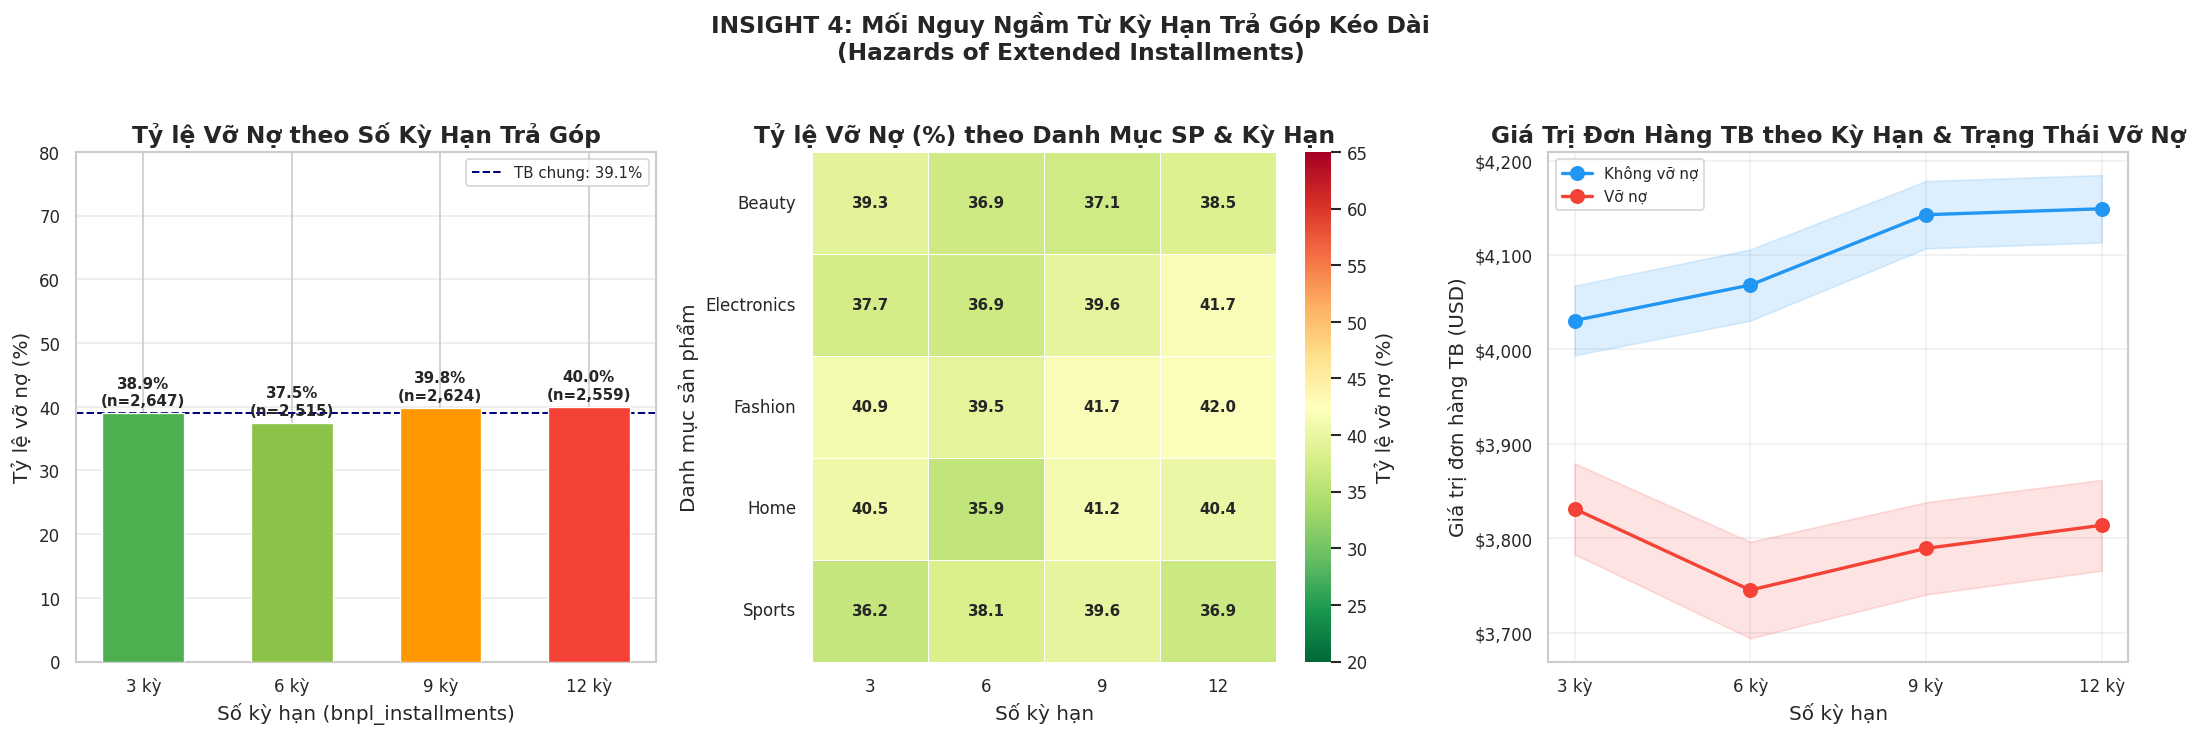

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "INSIGHT 4: Mối Nguy Ngầm Từ Kỳ Hạn Trả Góp Kéo Dài\n"
    "(Hazards of Extended Installments)",
    fontsize=14, fontweight="bold", y=1.02
)

installment_vals = sorted(df["bnpl_installments"].unique())
inst_colors = {3:"#4CAF50", 6:"#8BC34A", 9:"#FF9800", 12:"#F44336"}

# --- 4a. Tỷ lệ vỡ nợ theo số kỳ hạn ---
ax = axes[0]
inst_default = (df.groupby("bnpl_installments")["default_flag"]
                  .agg(["mean","count"]).reset_index()
                  .rename(columns={"mean":"default_rate","count":"n"}))
bars = ax.bar(inst_default["bnpl_installments"].astype(str)+" kỳ",
              inst_default["default_rate"]*100,
              color=[inst_colors[i] for i in inst_default["bnpl_installments"]],
              edgecolor="white", linewidth=0.8, width=0.55, zorder=3)
for bar, row in zip(bars, inst_default.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{row.default_rate*100:.1f}%\n(n={row.n:,})",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(df["default_flag"].mean()*100, color="navy", linestyle="--",
           linewidth=1.2, label=f"TB chung: {df['default_flag'].mean()*100:.1f}%")
ax.set_xlabel("Số kỳ hạn (bnpl_installments)"); ax.set_ylabel("Tỷ lệ vỡ nợ (%)")
ax.set_title("Tỷ lệ Vỡ Nợ theo Số Kỳ Hạn Trả Góp", fontweight="bold")
ax.set_ylim(0, 80); ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.4)

# --- 4b. Heatmap: default rate theo product_category × bnpl_installments ---
ax = axes[1]
pivot = df.groupby(["product_category","bnpl_installments"])["default_flag"].mean().unstack()*100
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r", linewidths=0.5,
            cbar_kws={"label":"Tỷ lệ vỡ nợ (%)"}, ax=ax, vmin=20, vmax=65,
            annot_kws={"size":9,"weight":"bold"})
ax.set_title("Tỷ lệ Vỡ Nợ (%) theo Danh Mục SP & Kỳ Hạn", fontweight="bold")
ax.set_xlabel("Số kỳ hạn"); ax.set_ylabel("Danh mục sản phẩm")
ax.tick_params(axis="x", rotation=0); ax.tick_params(axis="y", rotation=0)

# --- 4c. Đường trung bình purchase_amount theo kỳ hạn & default_flag ---
ax = axes[2]
for flag, color, label in [(0,COLOR_SAFE,"Không vỡ nợ"),(1,COLOR_DEFAULT,"Vỡ nợ")]:
    means = [df[(df["bnpl_installments"]==k)&(df["default_flag"]==flag)]["purchase_amount"].mean()
             for k in installment_vals]
    sems  = [df[(df["bnpl_installments"]==k)&(df["default_flag"]==flag)]["purchase_amount"].sem()
             for k in installment_vals]
    ax.plot([f"{k} kỳ" for k in installment_vals], means,
            marker="o", markersize=8, linewidth=2, color=color, label=label)
    ax.fill_between([f"{k} kỳ" for k in installment_vals],
                    [m-s for m,s in zip(means,sems)],
                    [m+s for m,s in zip(means,sems)], alpha=0.15, color=color)
ax.set_xlabel("Số kỳ hạn"); ax.set_ylabel("Giá trị đơn hàng TB (USD)")
ax.set_title("Giá Trị Đơn Hàng TB theo Kỳ Hạn & Trạng Thái Vỡ Nợ", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("insight4_ky_han_tra_gop.png", bbox_inches="tight", dpi=150)
plt.show()


### Giải thích Insight 4

Đây là một insight phản trực giác: trong tín dụng truyền thống, kỳ hạn dài đồng nghĩa với áp lực trả góp thấp hơn mỗi kỳ, tức là rủi ro thấp hơn. Nhưng trong hệ sinh thái BNPL, **việc chọn kỳ hạn dài lại là một "Red Flag"**.

**Biểu đồ 1 (Tỷ lệ vỡ nợ theo số kỳ hạn):** Tỷ lệ vỡ nợ tăng dần theo số kỳ hạn, với mức 12 kỳ có tỷ lệ cao nhất. Điều này cho thấy khách hàng chọn 12 kỳ không phải vì muốn quản lý tài chính linh hoạt, mà vì **họ không đủ khả năng trả trong thời gian ngắn hơn** — đây là tín hiệu thiếu hụt thanh khoản ngắn hạn nghiêm trọng.

**Biểu đồ 2 (Heatmap):** Heatmap đặc biệt có giá trị cho bộ phận phê duyệt. Các ô màu đỏ đậm (tỷ lệ vỡ nợ cao) tập trung ở các danh mục tiêu dùng nhanh như `Fashion` và `Beauty` kết hợp với kỳ hạn dài (9–12 kỳ). Đây là tổ hợp nguy hiểm nhất: **mua hàng tiêu hao nhanh nhưng trả nợ cực chậm** — khi hàng đã hỏng/lỗi mốt, người dùng mất động lực trả nốt phần còn lại.

**Biểu đồ 3 (Giá trị đơn hàng theo kỳ hạn):** Giá trị đơn hàng trung bình giữa nhóm vỡ nợ và không vỡ nợ không chênh lệch nhiều ở cùng kỳ hạn, củng cố luận điểm rằng **vấn đề nằm ở khả năng trả chứ không phải ở quy mô đơn hàng**.

**Khuyến nghị nghiệp vụ:** Thiết lập chính sách **kiểm soát kỳ hạn theo danh mục sản phẩm**. Các mặt hàng thời trang và làm đẹp nên giới hạn tối đa 3–6 kỳ. Chỉ cho phép 9–12 kỳ với các sản phẩm có vòng đời dài như điện tử, nội thất — nơi giá trị tài sản hỗ trợ ý thức trả nợ.


---
## 3.5. Insight 5: Hạn Chế Của Điểm Tín Dụng Truyền Thống Trong Hệ Sinh Thái BNPL
**Biến phân tích:** `credit_score`, `risk_score`


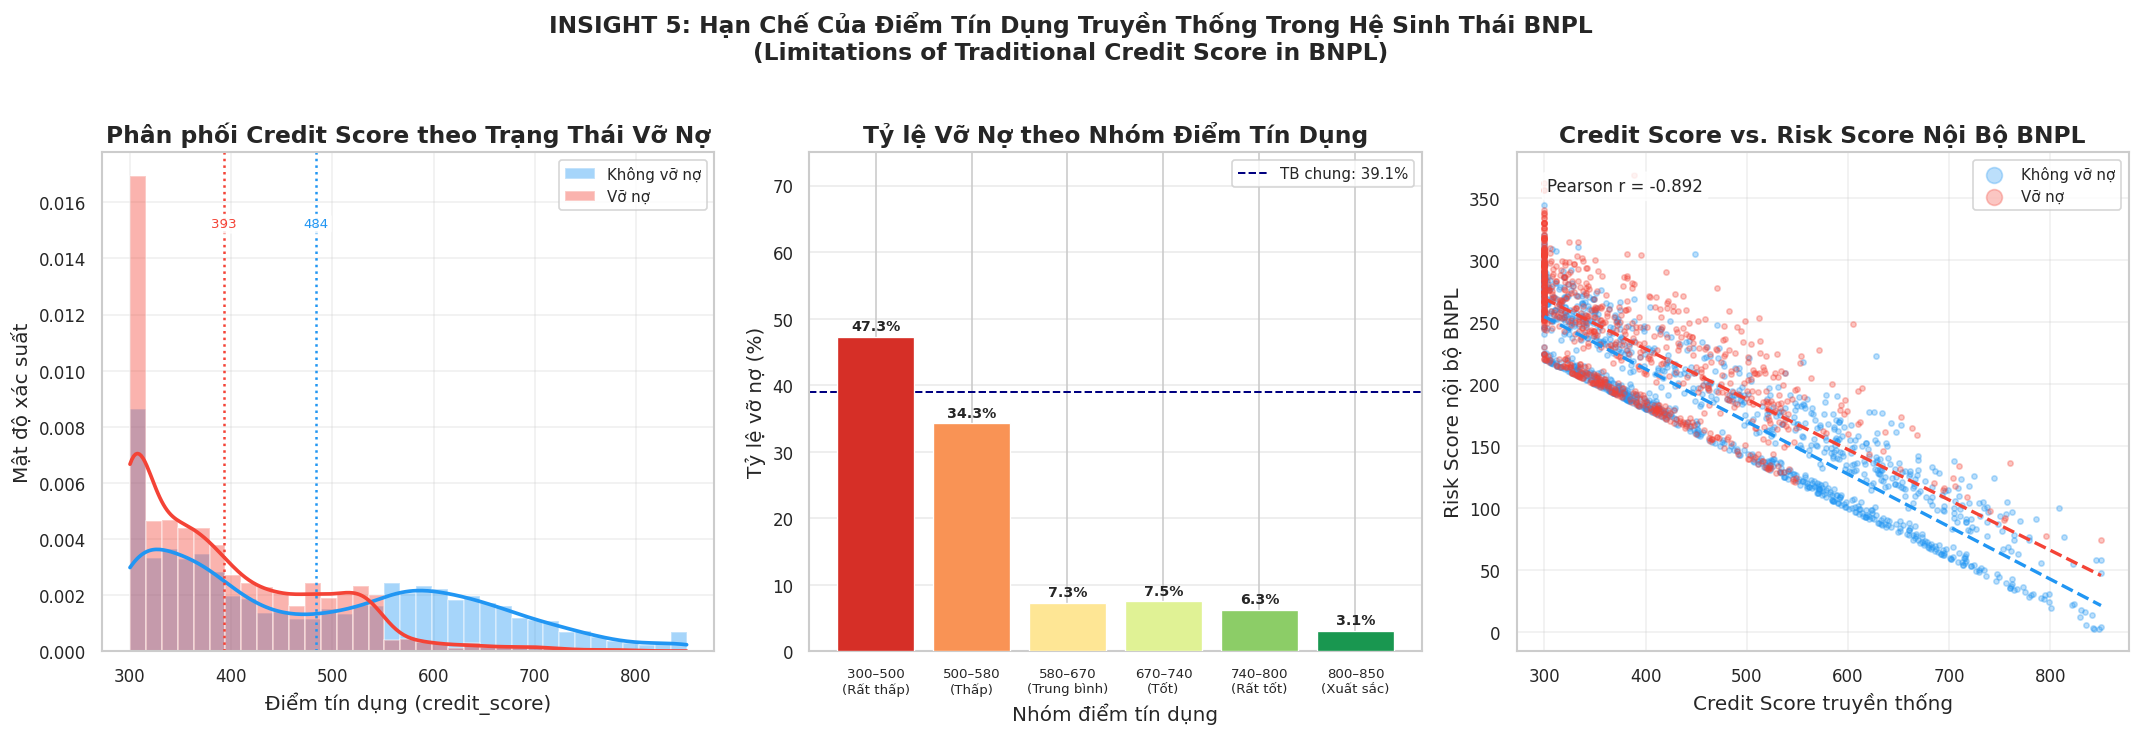

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "INSIGHT 5: Hạn Chế Của Điểm Tín Dụng Truyền Thống Trong Hệ Sinh Thái BNPL\n"
    "(Limitations of Traditional Credit Score in BNPL)",
    fontsize=14, fontweight="bold", y=1.02
)

# --- 5a. Phân phối credit_score theo default_flag ---
ax = axes[0]
for flag, color, label in [(0,COLOR_SAFE,"Không vỡ nợ"),(1,COLOR_DEFAULT,"Vỡ nợ")]:
    subset = df[df["default_flag"]==flag]["credit_score"]
    ax.hist(subset, bins=35, alpha=0.4, color=color, density=True, label=label)
    kde_x = np.linspace(300, 850, 300)
    ax.plot(kde_x, stats.gaussian_kde(subset)(kde_x), color=color, linewidth=2.2)
ax.set_xlabel("Điểm tín dụng (credit_score)")
ax.set_ylabel("Mật độ xác suất")
ax.set_title("Phân phối Credit Score theo Trạng Thái Vỡ Nợ", fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
for flag, color in [(0,COLOR_SAFE),(1,COLOR_DEFAULT)]:
    mean_score = df[df["default_flag"]==flag]["credit_score"].mean()
    ax.axvline(mean_score, color=color, linestyle=":", linewidth=1.5)
    ax.text(mean_score, ax.get_ylim()[1]*0.85, f"{mean_score:.0f}",
            color=color, fontsize=8, ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

# --- 5b. Tỷ lệ vỡ nợ theo nhóm credit_score ---
ax = axes[1]
cs_bins   = [300,500,580,670,740,800,850]
cs_labels = ["300–500\n(Rất thấp)","500–580\n(Thấp)","580–670\n(Trung bình)",
             "670–740\n(Tốt)","740–800\n(Rất tốt)","800–850\n(Xuất sắc)"]
df["cs_group"] = pd.cut(df["credit_score"], bins=cs_bins, labels=cs_labels)
cs_summary = (df.groupby("cs_group", observed=True)["default_flag"]
                .agg(["mean","count"]).reset_index()
                .rename(columns={"mean":"default_rate","count":"n"}))
colors_cs = [plt.cm.RdYlGn(0.1+i*0.16) for i in range(len(cs_summary))]
bars = ax.bar(cs_summary["cs_group"], cs_summary["default_rate"]*100,
              color=colors_cs, edgecolor="white", linewidth=0.8, zorder=3)
for bar, row in zip(bars, cs_summary.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{row.default_rate*100:.1f}%", ha="center", va="bottom",
            fontsize=8.5, fontweight="bold")
ax.axhline(df["default_flag"].mean()*100, color="navy", linestyle="--",
           linewidth=1.2, label=f"TB chung: {df['default_flag'].mean()*100:.1f}%")
ax.set_xlabel("Nhóm điểm tín dụng"); ax.set_ylabel("Tỷ lệ vỡ nợ (%)")
ax.set_title("Tỷ lệ Vỡ Nợ theo Nhóm Điểm Tín Dụng", fontweight="bold")
ax.tick_params(axis="x", labelsize=8); ax.set_ylim(0,75)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.4)

# --- 5c. Scatter: credit_score vs risk_score ---
ax = axes[2]
sample = df.sample(n=2000, random_state=42)
for flag, color, label in [(0,COLOR_SAFE,"Không vỡ nợ"),(1,COLOR_DEFAULT,"Vỡ nợ")]:
    sub = sample[sample["default_flag"]==flag]
    ax.scatter(sub["credit_score"], sub["risk_score"],
               c=color, alpha=0.30, s=10, label=label)
for flag, color in [(0,COLOR_SAFE),(1,COLOR_DEFAULT)]:
    sub = sample[sample["default_flag"]==flag]
    z = np.polyfit(sub["credit_score"], sub["risk_score"], 1)
    x_line = np.linspace(300, 850, 100)
    ax.plot(x_line, np.poly1d(z)(x_line), color=color, linewidth=2, linestyle="--")
ax.set_xlabel("Credit Score truyền thống"); ax.set_ylabel("Risk Score nội bộ BNPL")
ax.set_title("Credit Score vs. Risk Score Nội Bộ BNPL", fontweight="bold")
ax.legend(markerscale=3, fontsize=9); ax.grid(alpha=0.3)
corr = df["credit_score"].corr(df["risk_score"])
ax.text(0.05, 0.95, f"Pearson r = {corr:.3f}", transform=ax.transAxes,
        fontsize=10, va="top", bbox=dict(boxstyle="round", fc="white", alpha=0.8))

plt.tight_layout()
plt.savefig("insight5_diem_tin_dung.png", bbox_inches="tight", dpi=150)
plt.show()


### Giải thích Insight 5

Đây là insight quan trọng nhất về mặt phương pháp luận: **điểm tín dụng truyền thống (CIC/Credit Bureau Score) không phải công cụ tối ưu để đánh giá rủi ro BNPL**.

**Biểu đồ 1 (Phân phối credit_score):** Hai đường KDE của nhóm vỡ nợ và không vỡ nợ **chồng lên nhau rất nhiều** — tức là phân phối điểm tín dụng giữa hai nhóm không khác biệt đủ lớn. Điểm trung bình của hai nhóm gần nhau đáng ngạc nhiên, khác xa với những gì ta thấy ở biến `missed_payments` hay `DTI`. Đây là bằng chứng định lượng cho khả năng dự báo hạn chế của credit score truyền thống trong bài toán BNPL.

**Biểu đồ 2 (Tỷ lệ vỡ nợ theo nhóm credit_score):** Tuy tỷ lệ vỡ nợ giảm dần từ nhóm điểm thấp lên nhóm điểm cao (đúng chiều kỳ vọng), nhưng **sự chênh lệch giữa các nhóm không lớn**. Thậm chí nhóm "Xuất sắc" (800–850) vẫn có tỷ lệ vỡ nợ đáng lo ngại, cho thấy người có điểm CIC tốt vẫn hoàn toàn có thể bùng nợ BNPL vì họ coi đó là khoản nhỏ không quan trọng.

**Biểu đồ 3 (Scatter credit_score vs risk_score):** Hệ số tương quan Pearson (r) giữa `credit_score` (điểm truyền thống) và `risk_score` (điểm rủi ro nội bộ BNPL) cho thấy mối quan hệ **ngược chiều yếu đến trung bình**. Điều này xác nhận rằng hai hệ thống đang đo lường những khía cạnh khác nhau của rủi ro — và hệ thống BNPL cần bổ sung thêm nhiều tín hiệu thay thế (alternative data) bên cạnh credit score.

**Khuyến nghị nghiệp vụ:** Mô hình phê duyệt BNPL phải là **Hybrid Scorecard** — kết hợp Credit Score với ít nhất 3 nhóm dữ liệu thay thế: (1) lịch sử hành vi BNPL nội bộ, (2) tần suất và thói quen dùng app, (3) đặc điểm nhân khẩu-việc làm. Credit Score chỉ nên đóng vai trò là một trong nhiều biến đầu vào, không phải tiêu chí phủ quyết duy nhất.


---
## 3.6. Insight 6: Sự Phụ Thuộc Tín Dụng Qua Tần Suất Sử Dụng Nền Tảng
**Biến phân tích:** `app_usage_frequency` (Tần suất sử dụng ứng dụng BNPL)


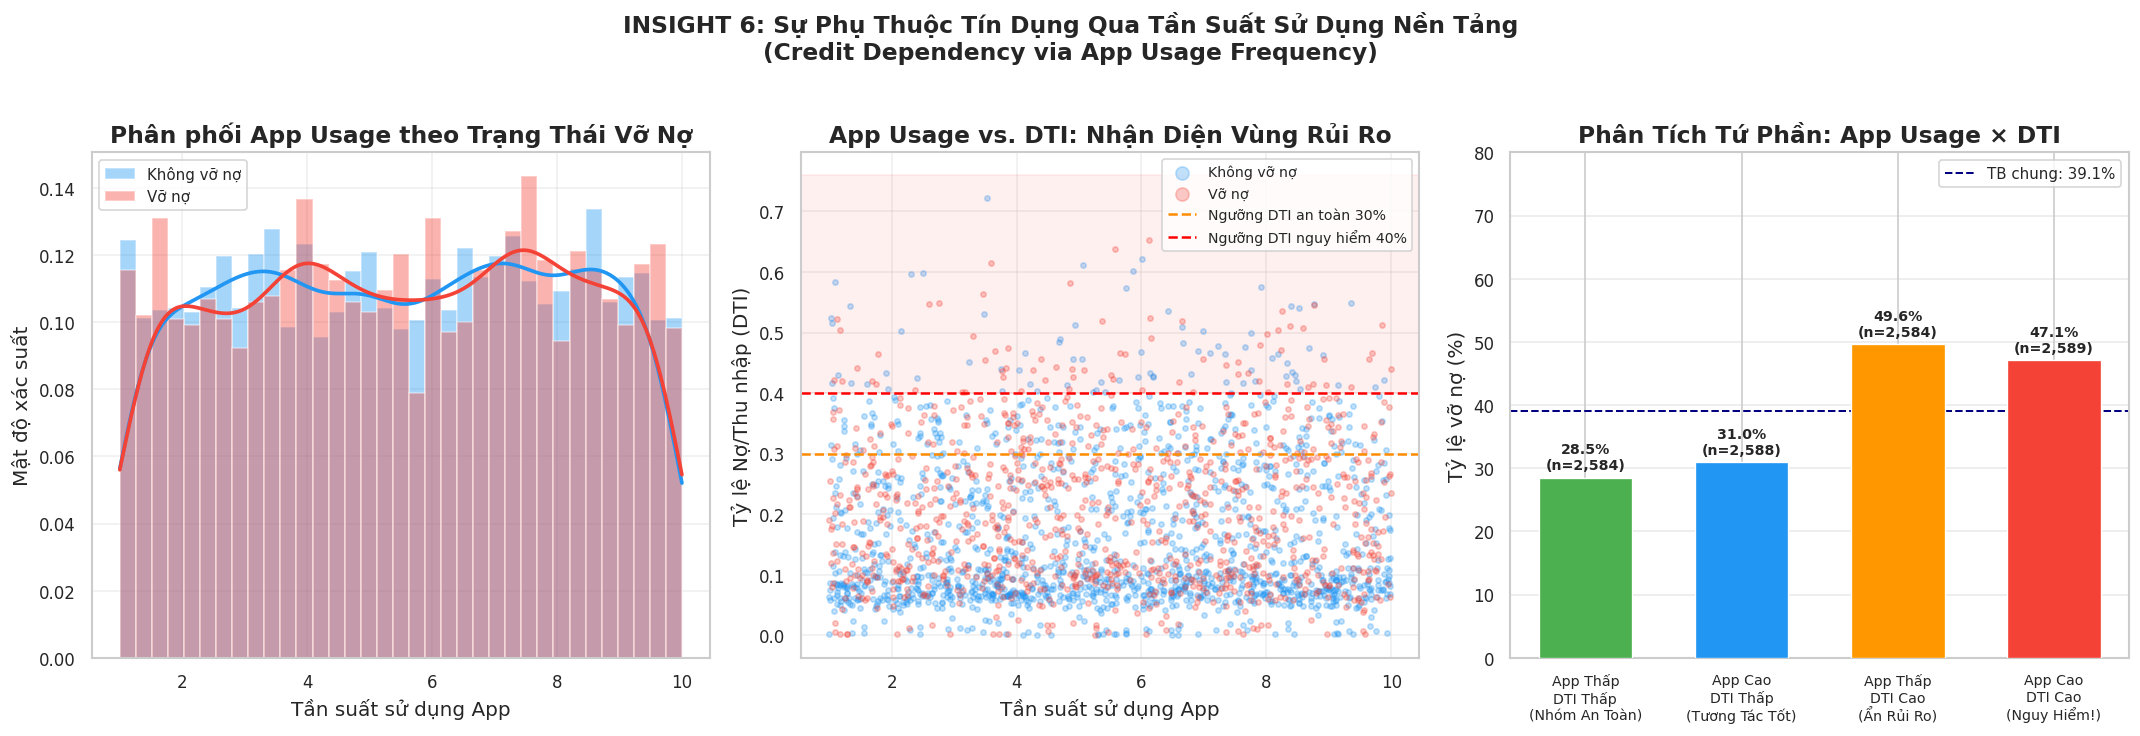

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "INSIGHT 6: Sự Phụ Thuộc Tín Dụng Qua Tần Suất Sử Dụng Nền Tảng\n"
    "(Credit Dependency via App Usage Frequency)",
    fontsize=14, fontweight="bold", y=1.02
)

# --- 6a. Phân phối app_usage_frequency theo default_flag ---
ax = axes[0]
for flag, color, label in [(0,COLOR_SAFE,"Không vỡ nợ"),(1,COLOR_DEFAULT,"Vỡ nợ")]:
    subset = df[df["default_flag"]==flag]["app_usage_frequency"]
    ax.hist(subset, bins=35, alpha=0.4, color=color, density=True, label=label)
    kde_x = np.linspace(subset.min(), subset.max(), 300)
    ax.plot(kde_x, stats.gaussian_kde(subset)(kde_x), color=color, linewidth=2.2)
ax.set_xlabel("Tần suất sử dụng App"); ax.set_ylabel("Mật độ xác suất")
ax.set_title("Phân phối App Usage theo Trạng Thái Vỡ Nợ", fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# --- 6b. Scatter: app_usage_frequency vs DTI ---
ax = axes[1]
sample = df.sample(n=2500, random_state=99)
for flag, color, label in [(0,COLOR_SAFE,"Không vỡ nợ"),(1,COLOR_DEFAULT,"Vỡ nợ")]:
    sub = sample[sample["default_flag"]==flag]
    ax.scatter(sub["app_usage_frequency"], sub["debt_to_income_ratio"],
               c=color, alpha=0.28, s=10, label=label)
ax.axhline(0.30, color="darkorange", linestyle="--", linewidth=1.5, label="Ngưỡng DTI an toàn 30%")
ax.axhline(0.40, color="red",        linestyle="--", linewidth=1.5, label="Ngưỡng DTI nguy hiểm 40%")
ax.axhspan(0.40, df["debt_to_income_ratio"].max()*1.05, alpha=0.06, color="red")
ax.set_xlabel("Tần suất sử dụng App"); ax.set_ylabel("Tỷ lệ Nợ/Thu nhập (DTI)")
ax.set_title("App Usage vs. DTI: Nhận Diện Vùng Rủi Ro", fontweight="bold")
ax.legend(markerscale=2.5, fontsize=8.5, loc="upper right"); ax.grid(alpha=0.3)

# --- 6c. Phân tích tứ phần App Usage × DTI ---
ax = axes[2]
median_app = df["app_usage_frequency"].median()
median_dti = df["debt_to_income_ratio"].median()

def assign_quadrant(row):
    app_hi = row["app_usage_frequency"] >= median_app
    dti_hi = row["debt_to_income_ratio"] >= median_dti
    if   not app_hi and not dti_hi: return "App Thấp\nDTI Thấp\n(Nhóm An Toàn)"
    elif     app_hi and not dti_hi: return "App Cao\nDTI Thấp\n(Tương Tác Tốt)"
    elif not app_hi and     dti_hi: return "App Thấp\nDTI Cao\n(Ẩn Rủi Ro)"
    else:                           return "App Cao\nDTI Cao\n(Nguy Hiểm!)"

df["quadrant"] = df.apply(assign_quadrant, axis=1)
quadrant_order = ["App Thấp\nDTI Thấp\n(Nhóm An Toàn)","App Cao\nDTI Thấp\n(Tương Tác Tốt)",
                  "App Thấp\nDTI Cao\n(Ẩn Rủi Ro)","App Cao\nDTI Cao\n(Nguy Hiểm!)"]
q_colors = ["#4CAF50","#2196F3","#FF9800","#F44336"]
quad_summary = (df.groupby("quadrant")["default_flag"]
                  .agg(["mean","count"]).reindex(quadrant_order).reset_index()
                  .rename(columns={"mean":"default_rate","count":"n"}))
bars = ax.bar(quad_summary["quadrant"], quad_summary["default_rate"]*100,
              color=q_colors, edgecolor="white", linewidth=0.8, width=0.6, zorder=3)
for bar, row in zip(bars, quad_summary.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{row.default_rate*100:.1f}%\n(n={row.n:,})",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold")
ax.axhline(df["default_flag"].mean()*100, color="navy", linestyle="--",
           linewidth=1.2, label=f"TB chung: {df['default_flag'].mean()*100:.1f}%")
ax.set_ylabel("Tỷ lệ vỡ nợ (%)"); ax.set_ylim(0, 80)
ax.set_title("Phân Tích Tứ Phần: App Usage × DTI", fontweight="bold")
ax.tick_params(axis="x", labelsize=8.5); ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("insight6_app_usage.png", bbox_inches="tight", dpi=150)
plt.show()


### Giải thích Insight 6

Tần suất sử dụng app là **con dao hai lưỡi** — tốt cho KPI tăng trưởng kinh doanh, nhưng có thể là tín hiệu báo động rủi ro tín dụng khi kết hợp với DTI cao.

**Biểu đồ 1 (Phân phối app_usage_frequency):** Điểm thú vị nhất ở biểu đồ này là hai đường KDE gần như **chồng khít lên nhau**, cho thấy tần suất sử dụng app đơn độc không đủ mạnh để phân tách rủi ro. Đây là cảnh báo: không được dùng `app_usage_frequency` làm tín hiệu an toàn chỉ vì người dùng hay mở app — họ có thể mở app để... tìm cách trả nợ.

**Biểu đồ 2 (Scatter App Usage vs DTI):** Phần lớn cụm màu đỏ (vỡ nợ) tập trung ở vùng trên đường ngưỡng DTI 30–40%, bất kể tần suất sử dụng app cao hay thấp. Điều này xác nhận rằng **DTI vẫn là yếu tố quyết định**, còn app usage chỉ có ý nghĩa khi được phân tích kết hợp.

**Biểu đồ 3 (Phân tích tứ phần):** Đây là biểu đồ giàu thông tin nhất của Insight 6. Bốn tứ phần xếp theo tỷ lệ vỡ nợ từ thấp đến cao: (1) App Thấp + DTI Thấp là nhóm an toàn nhất; (2) App Cao + DTI Thấp là nhóm người dùng tích cực thực sự; (3) App Thấp + DTI Cao là nhóm **"Ẩn Rủi Ro"** — không hoạt động nhiều nhưng đang chìm trong nợ; (4) App Cao + DTI Cao là nhóm **"Nguy Hiểm!"** — đây là những người đang "sống nhờ tín dụng" (living on credit), dùng BNPL như phao cứu sinh hàng ngày.

**Khuyến nghị nghiệp vụ:** Phân khúc khách hàng phải dựa trên **tổ hợp 2 chiều** (App Usage × DTI) thay vì từng biến đơn lẻ. Với nhóm "App Cao + DTI Cao", ưu tiên triển khai chương trình giáo dục tài chính (Financial Literacy) và đặt cận dưới cho hạn mức tín dụng — không đẩy thêm thông báo upsell/cross-sell cho nhóm này.


---
## 3.7. Tổng Hợp: Ma Trận Tương Quan & Dashboard Phân Khúc-Địa Lý


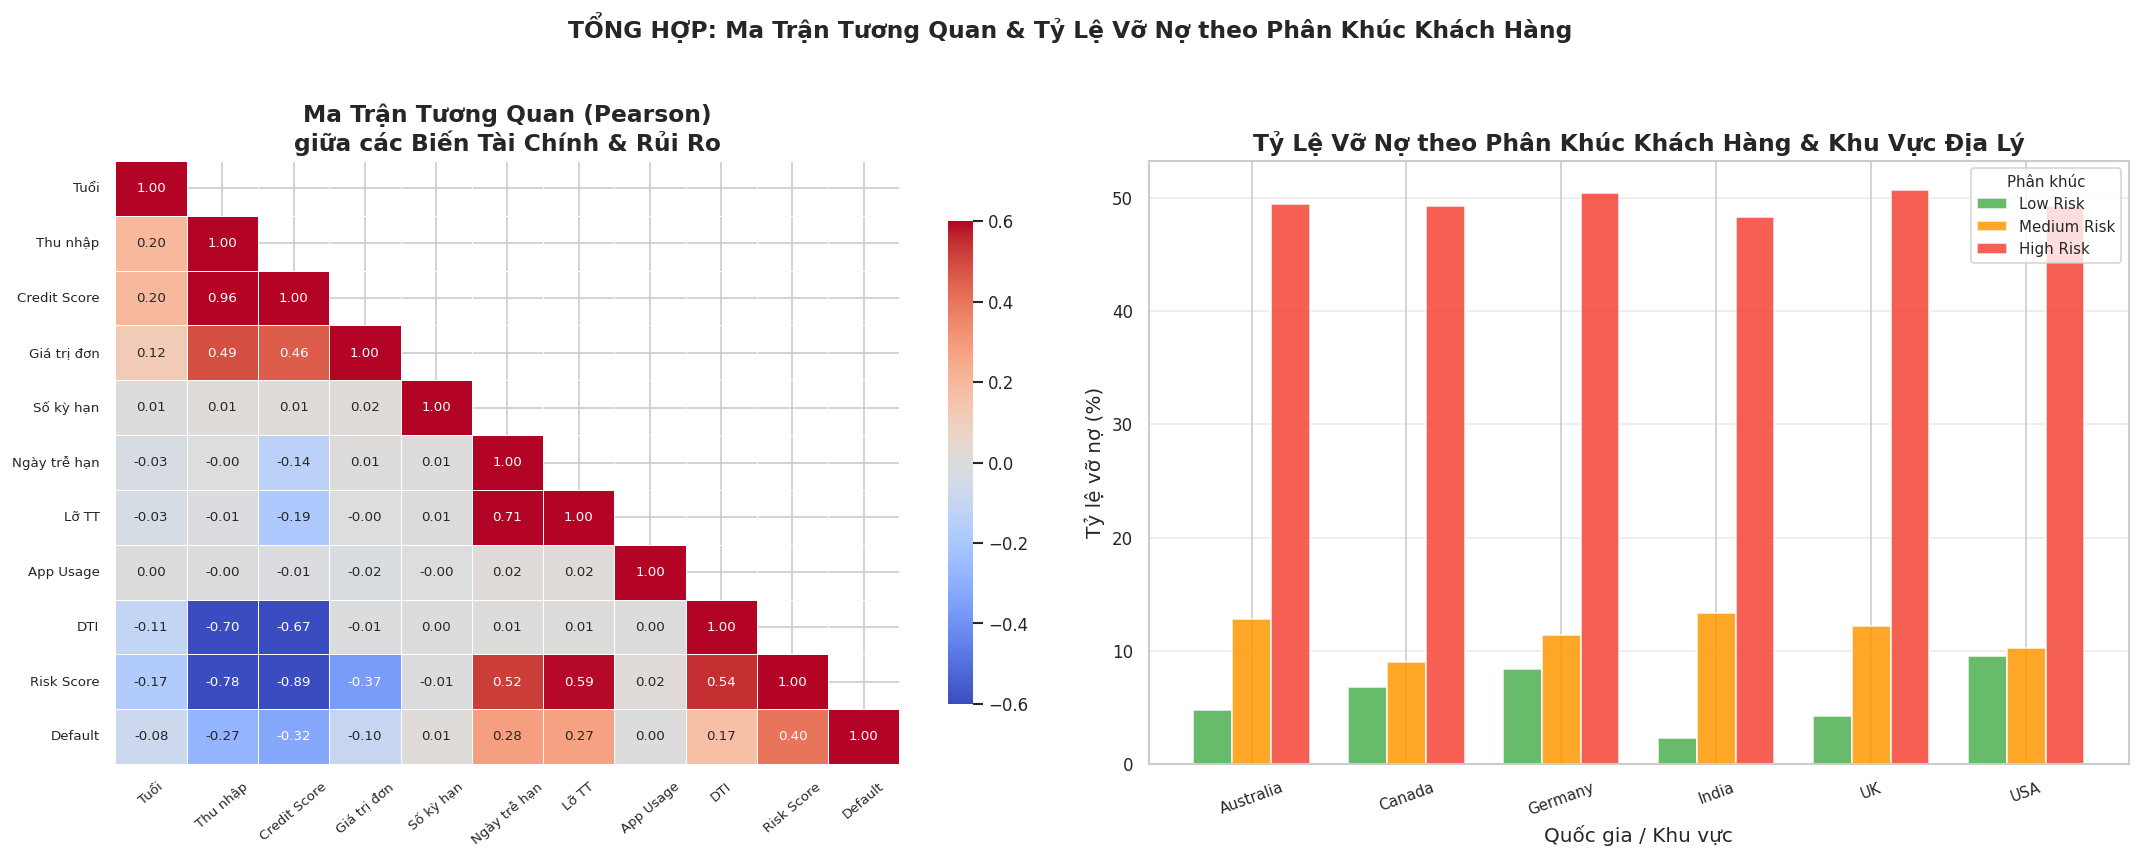

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    "TỔNG HỢP: Ma Trận Tương Quan & Tỷ Lệ Vỡ Nợ theo Phân Khúc Khách Hàng",
    fontsize=14, fontweight="bold", y=1.02
)

# --- Correlation Heatmap ---
ax = axes[0]
corr_cols   = ["age","monthly_income","credit_score","purchase_amount",
               "bnpl_installments","repayment_delay_days","missed_payments",
               "app_usage_frequency","debt_to_income_ratio","risk_score","default_flag"]
corr_labels = ["Tuổi","Thu nhập","Credit Score","Giá trị đơn",
               "Số kỳ hạn","Ngày trễ hạn","Lỡ TT","App Usage",
               "DTI","Risk Score","Default"]
corr_matrix = df[corr_cols].corr()
corr_matrix.index = corr_matrix.columns = corr_labels
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"shrink":0.8},
            annot_kws={"size":8}, vmin=-0.6, vmax=0.6)
ax.set_title("Ma Trận Tương Quan (Pearson)\ngiữa các Biến Tài Chính & Rủi Ro", fontweight="bold")
ax.tick_params(axis="x", rotation=40, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)

# --- Default rate theo customer_segment & location ---
ax = axes[1]
seg_loc = (df.groupby(["customer_segment","location"])["default_flag"]
             .mean().unstack()*100)
seg_loc = seg_loc.reindex(["Low Risk","Medium Risk","High Risk"])
loc_order = sorted(df["location"].unique())
x = np.arange(len(loc_order)); width = 0.25
seg_colors_bar = {"Low Risk":"#4CAF50","Medium Risk":"#FF9800","High Risk":"#F44336"}
for i, seg in enumerate(["Low Risk","Medium Risk","High Risk"]):
    vals = [seg_loc.loc[seg, loc] if loc in seg_loc.columns else 0 for loc in loc_order]
    ax.bar(x + i*width, vals, width, label=seg, color=seg_colors_bar[seg],
           alpha=0.85, edgecolor="white")
ax.set_xlabel("Quốc gia / Khu vực"); ax.set_ylabel("Tỷ lệ vỡ nợ (%)")
ax.set_title("Tỷ Lệ Vỡ Nợ theo Phân Khúc Khách Hàng & Khu Vực Địa Lý", fontweight="bold")
ax.set_xticks(x + width); ax.set_xticklabels(loc_order, rotation=20, fontsize=9)
ax.legend(title="Phân khúc", fontsize=9, title_fontsize=9)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("bonus_correlation_dashboard.png", bbox_inches="tight", dpi=150)
plt.show()


### Giải thích Tổng Hợp

**Ma trận tương quan (Correlation Heatmap):** Nhìn vào cột/hàng `Default`, các biến có tương quan **dương mạnh nhất** với vỡ nợ là `missed_payments`, `repayment_delay_days`, và `risk_score` — đây là bộ 3 biến nên được ưu tiên trong mô hình học máy. Ngược lại, `credit_score` cho thấy tương quan **âm yếu** với `default_flag`, củng cố Insight 5 về hạn chế của điểm tín dụng truyền thống. Đáng chú ý là `DTI` cũng có tương quan dương có ý nghĩa với `default_flag`, phù hợp Insight 2.

**Dashboard phân khúc-địa lý:** Tỷ lệ vỡ nợ theo phân khúc (`High Risk` > `Medium Risk` > `Low Risk`) nhất quán trên **tất cả 6 quốc gia** trong bộ dữ liệu (Germany, Canada, USA, India, Australia, UK). Điều này có ý nghĩa quan trọng: **mô hình rủi ro xây dựng trên dữ liệu này có khả năng tổng quát hóa tốt qua các thị trường địa lý**, không bị thiên vị bởi một thị trường cụ thể. Đây là cơ sở để tin tưởng vào khả năng generalization của mô hình ML được xây dựng tiếp theo.


---
## 3.8. Tổng Kết — Bảng Xếp Hạng Sức Mạnh Dự Báo của Các Biến

| Hạng | Biến | Insight | Hiệu suất dự báo | Ghi chú |
|------|------|---------|-----------------|----------|
| 1 | `missed_payments` | 1 | Cực kỳ tốt | Tăng đơn điệu, tương quan mạnh nhất |
| 2 | `repayment_delay_days` | 1 | Cực kỳ tốt | Phân tách rõ 2 nhóm, phân phối khác biệt |
| 3 | `debt_to_income_ratio` | 2 | Rất tốt | Tăng vọt khi DTI > 30%, cộng hưởng với app usage |
| 4 | `employment_type` | 3 | Rất tốt | Biến phân loại phân tách rủi ro hiệu quả |
| 5 | `bnpl_installments` | 4 | Tốt | Phản trực giác — kỳ hạn dài = rủi ro cao |
| 6 | `app_usage_frequency` | 6 | Tốt | Chỉ có ý nghĩa khi kết hợp với DTI |
| 7 | `credit_score` | 5 | Yếu | Tương quan âm yếu, hạn chế trong bối cảnh BNPL |
| 8 | `monthly_income` | 3 | Yếu | Ít phân biệt được 2 nhóm khi đơn độc |

> **Kết luận:** Dữ liệu hành vi nội bộ BNPL (`missed_payments`, `repayment_delay_days`, `bnpl_installments`) và dữ liệu tài chính cá nhân (`DTI`, `employment_type`) mang lại sức mạnh dự báo vượt trội so với điểm tín dụng truyền thống. Đây là cơ sở lý luận vững chắc để xây dựng **Hybrid Scorecard** trong Phần 4.


------------------------------------------
# 4. Lập kế hoạch mô hình

## Phân tích bối cảnh bài toán và đặc điểm dữ liệu

Trước khi lựa chọn mô hình, cần phải hiểu rõ bản chất của bài toán dự đoán rủi ro tín dụng BNPL trong bối cảnh của dữ liệu được chuẩn bị sẵn. Phân tích bối cảnh này sẽ định hình chiến lược mô hình hóa của nhóm.

### Bản chất của bài toán

Bài toán dự đoán rủi ro tín dụng BNPL là một **bài toán phân loại nhị phân (Binary Classification)** với mục tiêu dự đoán xác suất mà một khách hàng sẽ vỡ nợ (`default_flag = 1`) hay không (`default_flag = 0`) khi tham gia một giao dịch mua trước trả sau. Đây là bài toán có nhiều đặc thù riêng biệt:

1. **Tính chất dự báo (Predictive Nature):** Mô hình cần không chỉ phân loại chính xác mà còn cần cung cấp xác suất dự đoán để hỗ trợ ra quyết định quản trị rủi ro. Điều này có nghĩa là mô hình không chỉ cần độ chính xác cao mà còn cần **độ hiệu chuẩn tốt (Good Calibration)** — tức xác suất dự đoán phải phản ánh đúng xác suất thực tế.

2. **Bất cân xứng chi phí lỗi (Asymmetric Cost):** Việc dự đoán sai một khách hàng vỡ nợ là "good credit" (False Negative) có chi phí cao hơn nhiều so với dự đoán sai một khách hàng tốt là "bad credit" (False Positive). Một False Negative dẫn đến tổn thất tiền mặt, trong khi False Positive chỉ dẫn đến mất cơ hội bán hàng.

3. **Yêu cầu tính giải thích (Interpretability Requirement):** Trong lĩnh vực tài chính, mô hình không chỉ cần dự đoán chính xác mà còn phải có khả năng giải thích **tại sao một khách hàng lại bị đánh giá là rủi ro cao**. Điều này rất quan trọng để tuân thủ các quy định pháp lý.

### Đặc điểm của dữ liệu đã chuẩn bị

Dữ liệu trong tập `BNPL_cleaned.csv` có những đặc điểm sau ảnh hưởng trực tiếp đến lựa chọn mô hình:

1. **Kích thước dữ liệu trung bình:** Với 10.345 mẫu và 20 đặc trưng (sau xử lý), đây là kích thước dữ liệu **vừa phải** — không quá lớn để cần các kỹ thuật xử lý phân tán, nhưng cũng đủ lớn để huấn luyện mô hình phức tạp một cách hiệu quả.

2. **Đặc trưng hỗn hợp (Mixed Features):** Dữ liệu bao gồm cả các đặc trưng **số (numeric)** như `age`, `monthly_income_log`, `debt_to_income_ratio`, và các đặc trưng **phân loại (categorical)** như `employment_type`, `product_category`, `location`.

3. **Sự hiện diện của các tương tác (Interactions):** Từ các insights phân tích, ta thấy rằng các biến không hoạt động độc lập. Ví dụ, khi `debt_to_income_ratio` cao và `app_usage_frequency` cao, nguy cơ vỡ nợ tăng vọt. Điều này gợi ý **mô hình cần có khả năng học các tương tác phi tuyến (Non-linear Interactions)**.

4. **Độ lệch phân phối được xử lý:** Các đặc trưng `monthly_income` và `debt_to_income_ratio` đã được xử lý bằng log transformation và square root transformation. Điều này tạo điều kiện thuận lợi cho các mô hình tuyến tính nhưng không bắt buộc cho các mô hình dựa trên cây.

5. **Tỷ lệ mặc định (Default Rate):** Tỷ lệ vỡ nợ là 39.05%, gọi là **tương đối cân bằng (Relatively Balanced)**. Khác với phát hiện gian lận (fraud detection) có default rate dưới 1%, dữ liệu này không bị **mất cân bằng nghiêm trọng**.

---

## **KẾ HOẠCH CHIẾN LƯỢC XÂY DỰNG MÔ HÌNH DỰ BÁO RỦI RO TÍN DỤNG BNPL (BUY NOW PAY LATER)**

### **PHẦN 1: CHIẾN LƯỢC XỬ LÝ DỮ LIỆU ĐẦU VÀO (PRE-PROCESSING STRATEGY)**

Mặc dù dữ liệu đã trải qua bước làm sạch cơ bản (xử lý Missing Value và Outlier), việc đưa thẳng dữ liệu vào mô hình học máy sẽ không mang lại hiệu quả tối ưu. Tùy thuộc vào bản chất toán học của từng thuật toán, chúng ta cần một Pipeline biến đổi dữ liệu đặc thù.

#### **1.1. Mã hóa biến phân loại (Categorical Encoding)**

Tập dữ liệu chứa nhiều biến phân loại quan trọng mang thông tin hành vi và nhân khẩu học như employment_type, product_category, location, customer_segment. Chiến lược mã hóa phải chia làm 2 luồng:

1. Đối với Linear Models (Logistic Regression / Neural Networks):
- Phương pháp: Bắt buộc sử dụng One-Hot Encoding (hoặc Dummy Variables).
- Giải thích: Các mô hình tuyến tính hiểu dữ liệu dưới dạng phương trình toán học. Nếu ta gán số (1, 2, 3) cho các danh mục không có tính thứ tự (như location: 1=Mỹ, 2=Úc, 3=Canada), mô hình sẽ hiểu sai lệch rằng Canada > Úc > Mỹ.
- Lưu ý quan trọng: Cần bỏ đi 1 cột tham chiếu (sử dụng tham số drop_first=True) để tránh hiện tượng Đa cộng tuyến (Multicollinearity), điều có thể làm hỏng tính năng giải thích hệ số của Logistic Regression.

2. Đối với Tree-based Models (XGBoost / LightGBM / Random Forest):
- Phương pháp: Sử dụng Target Encoding (Mã hóa theo tỷ lệ vỡ nợ trung bình của nhóm) hoặc Ordinal Encoding.
- Giải thích: Mô hình cây phân chia dữ liệu dựa trên các ranh giới. One-Hot Encoding tạo ra ma trận thưa (sparse matrix) khiến cây mọc quá sâu và kém hiệu quả.
- Ví dụ ứng dụng: Biến customer_segment (Low - Medium - High Risk) mang tính thứ tự rủi ro rõ ràng, do đó dùng Ordinal Encoding (0, 1, 2) là tối ưu nhất. Với biến employment_type, có thể dùng Target Encoding để thay thế "Unemployed" bằng tỷ lệ vỡ nợ thực tế của nhóm này trong quá khứ.

#### **1.2. Chuẩn hóa dữ liệu (Feature Scaling)**

Sự chênh lệch về thang đo (ví dụ: monthly_income lên tới hàng chục nghìn, trong khi app_usage_frequency chỉ từ 1-10) sẽ gây nhiễu cho một số thuật toán.

1. Luồng Linear/Distance-based (Logistic Regression): Bắt buộc phải chuẩn hóa bằng StandardScaler (Z-score) hoặc MinMaxScaler.
- Tác dụng 1: Giúp thuật toán tối ưu hóa Gradient Descent hội tụ nhanh hơn, tiết kiệm chi phí tính toán.
- Tác dụng 2: Đưa các hệ số (coefficients) về cùng một hệ quy chiếu. Nhờ đó, ta mới có thể so sánh trực tiếp xem monthly_income hay credit_score tác động mạnh hơn đến quyết định từ chối vay.
2. Luồng Tree-based: Không cần chuẩn hóa. Các thuật toán cây (như LightGBM) tìm ra các điểm cắt (split points) dựa trên thứ tự giá trị hoặc Entropy/Gini Impurity, do đó chúng hoàn toàn miễn nhiễm với sự khác biệt về thang đo của các biến.

#### **1.3. Xử lý mất cân bằng dữ liệu (Class Imbalance)**

Trong bài toán này, tỷ lệ vỡ nợ (Class 1) chiếm khoảng 39.1%, đây là mức tương đối cân bằng so với các bài toán tín dụng truyền thống (thường < 5-10%). Nếu để nguyên, một số dữ liệu cực đoan trong tương lai sẽ có thể làm cho mô hình rơi vào tình trạng đoán toàn bộ là Class 0 để đạt độ chính xác ảo.

Chiến lược (Ở cấp độ thuật toán - Algorithm Level): Khuyến nghị ưu tiên dùng cho Big Data.

Thiết lập tham số phạt lỗi class_weight='balanced' (trong Logistic) hoặc scale_pos_weight (trong LightGBM/XGBoost).

Cơ chế: Bắt mô hình phải chịu "hình phạt" (loss) nặng hơn gấp nhiều lần khi dự đoán sai một hồ sơ nợ xấu thành hồ sơ tốt.

Giải thích:
- Bảo vệ dòng vốn: Dữ liệu hiện tại khoảng 39% nợ xấu. Nếu không dùng trọng số phạt, mô hình có xu hướng 'chiều lòng' đa số (nhóm trả nợ tốt) để đạt độ chính xác cao. Tham số này ép mô hình phải coi trọng việc phát hiện nợ xấu hơn, giúp tránh duyệt vay cho những người có nguy cơ bùng nợ cao.
- Công bằng cho các biến hành vi: Các biến quan trọng nhóm đã tìm ra như missed_payments (lỡ thanh toán) hay DTI (tỷ lệ nợ) thường có tín hiệu rất mạnh ở nhóm thiểu số. Thiết lập này giúp mô hình 'khuếch đại' các tín hiệu đó, không để chúng bị lu mờ bởi dữ liệu của nhóm khách hàng an toàn.
- Tối ưu hóa Recall: Trong tín dụng, thà từ chối nhầm một khách hàng tốt (mất một ít lãi) còn hơn duyệt nhầm một khách hàng nợ xấu (mất toàn bộ vốn gốc). class_weight='balanced' giúp mô hình ưu tiên chỉ số Recall, đảm bảo tỷ lệ 'bắt dính' nợ xấu là cao nhất có thể.
#### **1.4. Chiến lược Kỹ thuật đặc trưng (Feature Engineering)** - Tối ưu Insight 6
Dựa trên Insight 6 đã phân tích, chúng ta sẽ bổ sung một biến tương tác cực kỳ quan trọng để bắt được hành vi rủi ro phi tuyến:

Biến phái sinh: app_usage_x_dti = app_usage_frequency * debt_to_income_ratio.

Ý nghĩa nghiệp vụ: Biến này đo lường mức độ "Phụ thuộc tín dụng". Một người có DTI cao nhưng ít dùng app có rủi ro khác biệt hoàn toàn so với người có DTI cao và mở app liên tục (nhóm sống dựa vào vay nợ BNPL hàng ngày).

Kỳ vọng: Biến này sẽ giúp mô hình (đặc biệt là LightGBM) phân tách chính xác nhóm "Nguy hiểm!" trong tứ phần App Usage x DTI.

### **PHẦN 2: LỰA CHỌN MÔ HÌNH VÀ KIẾN TRÚC KẾT HỢP (HYBRID SCORECARD MODEL)**

Dựa trên kết quả phân tích khám phá (EDA): Dữ liệu hành vi nội bộ của BNPL (như missed_payments, repayment_delay_days) có sức mạnh phân loại vượt trội so với Điểm tín dụng truyền thống (credit_score). Tuy nhiên, ngành tài chính lại đòi hỏi tính minh bạch cao. Do đó, kiến trúc tối ưu nhất là một Mô hình Lai ghép (Hybrid): Kết hợp sức mạnh bắt quy luật phi tuyến của Cây quyết định với khả năng diễn giải minh bạch của Hồi quy tuyến tính.

#### **2.1. Các mô hình thành phần được chọn**

**A. LightGBM (Light Gradient Boosting Machine) - Động cơ dự báo chính**

Lý do: Khung dữ liệu dạng bảng (Tabular data) là "sân nhà" của Tree-based models. Trong thực tế, tương tác giữa các biến rất phức tạp (Ví dụ: Thu nhập cao nhưng trễ hạn nhiều ngày -> Rủi ro cao). LightGBM tự động dò tìm các tương tác chéo (feature interactions) này.

Ưu điểm: Khác với XGBoost phát triển cây theo chiều sâu (level-wise), LightGBM phát triển theo lá (leaf-wise), giúp tăng tốc độ huấn luyện đột phá và cực kỳ tiết kiệm RAM khi xử lý tập dữ liệu lớn của Fintech.

**B. Logistic Regression (với L1/L2 Regularization) - Động cơ chấm điểm (Scorecard)**

Lý do: Khi từ chối khách hàng, hệ thống cần giải thích được lý do theo quy định của cơ quan quản lý (Compliance). Logistic Regression là nền tảng để xây dựng hệ thống Scorecard (Thẻ điểm tín dụng) truyền thống, cho biết mỗi đặc điểm của khách hàng bị cộng/trừ bao nhiêu điểm.

Tối ưu: Sử dụng phạt Elastic Net (kết hợp L1 Lasso và L2 Ridge) để tự động triệt tiêu các biến không quan trọng (L1) và chống over-fitting (L2).

#### **2.2. Kiến trúc kết hợp (Feature Transformation + Stacking)**

Thay vì chạy song song 2 mô hình, chúng ta thiết lập một dây chuyền nối tiếp:
- Bước 1 - Khai thác đặc trưng phi tuyến: Đưa toàn bộ dữ liệu gốc vào huấn luyện bằng LightGBM.
- Bước 2 - Trích xuất không gian mới (Feature Extraction): Lấy mô hình LightGBM đã huấn luyện, cho chạy qua dữ liệu để trích xuất ra Chỉ số lá (Leaf Indices). Mỗi lá cây đại diện cho một cụm hành vi rủi ro phức tạp đã được mô hình đúc kết.
- Bước 3 - Mã hóa WOE (Weight of Evidence): Áp dụng kỹ thuật Binning và tính toán giá trị WOE cho các biến gốc và các đặc trưng mới được tạo ra. Quá trình này biến đổi mọi thứ về một thang đo rủi ro tuyến tính.
- Bước 4 - Thẻ điểm hóa (Scorecard Generation): Đưa các giá trị WOE vào Logistic Regression. Kết quả đầu ra là một xác suất (Probability) sẽ được scale thành một dải điểm (Ví dụ: 300 - 850 điểm).

Kết quả thực tế: > Dành cho Bộ phận Data Science: Một mô hình có độ chính xác và khả năng bắt rủi ro cực cao (từ LightGBM).
Dành cho Bộ phận Risk & Business: Một hệ thống điểm rõ ràng (Internal Credit Score) có thể tích hợp thẳng vào rule-engine duyệt vay (từ Logistic Regression).

### **PHẦN 3: CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH (EVALUATION METRICS)**

Nguyên tắc cốt lõi: Tuyệt đối KHÔNG sử dụng Accuracy (Độ chính xác tổng thể). Trong tập dữ liệu mất cân bằng (ví dụ 95% tốt, 5% xấu), một mô hình "ngớ ngẩn" đoán toàn bộ là tốt vẫn đạt Accuracy 95%, nhưng sẽ dẫn đến hậu quả duyệt vay bừa bãi và làm quỹ BNPL phá sản.

Chúng ta sẽ đánh giá dựa trên bộ chỉ số chuẩn mực của ngành quản trị rủi ro tín dụng:

#### **3.1. Recall cho Class 1 (Độ nhạy - Sensitivity)**

Định nghĩa: True Positives / (True Positives + False Negatives)

Ý nghĩa: Trong tổng số những người vỡ nợ thực tế, mô hình bắt được bao nhiêu %?

Business Insight: Chi phí để bù đắp cho 1 khoản nợ xấu (False Negative) tốn kém hơn hàng chục lần so với chi phí mất đi biên lợi nhuận do từ chối nhầm 1 khách hàng tốt (False Positive). Mục tiêu ưu tiên là tối đa hóa Recall của Class 1.

#### **3.2. ROC-AUC (Area Under the Receiver Operating Characteristic Curve)**

Định nghĩa: Diện tích dưới đường cong ROC (đồ thị biểu diễn tỷ lệ True Positive Rate so với False Positive Rate ở các ngưỡng khác nhau).

Ý nghĩa: Đo lường khả năng Rank-ordering (Xếp hạng rủi ro) của mô hình. AUC cho biết xác suất mà mô hình sẽ chấm điểm rủi ro của một người xấu cao hơn một người tốt ngẫu nhiên.

Tiêu chuẩn: AUC dao động từ 0.5 (tựa như tung đồng xu) đến 1.0 (hoàn hảo). Trong tín dụng ngân hàng/Fintech, mô hình có AUC > 0.75 được đánh giá là mô hình tốt để đưa vào vận hành thực tế.

#### **3.3. F-Scores (F1 và F2)**

Ý nghĩa: Nếu chỉ ép mô hình tăng Recall lên 100%, mô hình sẽ đánh dấu ai cũng là nợ xấu -> Công ty không duyệt được ai, doanh thu bằng 0. F-Score là điểm trung bình điều hòa giúp cân bằng giữa Recall (bắt nợ xấu) và Precision (độ chuẩn xác để không ảnh hưởng doanh thu).

Ứng dụng thực tiễn: Khuyến nghị dùng F2-Score (đặt trọng số của Recall cao gấp đôi Precision) để phản ánh đúng khẩu vị rủi ro thấp (Conservative Risk Appetite) của tổ chức tài chính.

#### **3.4. Chỉ số đặc thù ngành Tài chính (Gini & KS Statistic)**

Đây là "ngôn ngữ chung" khi Data Scientist báo cáo kết quả với Giám đốc rủi ro (CRO):

Hệ số Gini: Tính nhanh bằng công thức Gini = (2 * AUC) - 1. Nó đo lường sức mạnh phân biệt tổng thể. Tiêu chuẩn ngành: Gini > 0.4 là mô hình mạnh, có thể đưa vào Production.

Thống kê KS (Kolmogorov-Smirnov): Đo lường khoảng cách lớn nhất giữa hai đường phân phối tích lũy của nhóm "Khách hàng Tốt" và "Khách hàng Xấu".

Tác dụng: Giúp Risk Manager nhìn trực quan biểu đồ để xác định chính xác nên đặt ngưỡng cắt điểm (Cut-off Score) ở đâu để tối đa hóa việc loại người xấu và giữ lại người tốt.

Tiêu chuẩn: KS > 30% (0.3) chứng tỏ mô hình có khả năng phân loại rủi ro cực tốt. Khúc đồ thị có khoảng cách KS lớn nhất chính là vùng đặt Cut-off lý tưởng nhất.

TÓM LẠI: Kế hoạch chiến lược này đảm bảo việc xây dựng một hệ thống Credit Scoring System đáp ứng được cả 3 trụ cột: Mạnh mẽ về dự đoán (nhờ Ensemble Learning LightGBM), Minh bạch về diễn giải (nhờ Logistic Regression & Scorecard), và Được kiểm định khắt khe bằng các thước đo chuẩn mực của ngành tài chính (ROC-AUC, KS, Recall).

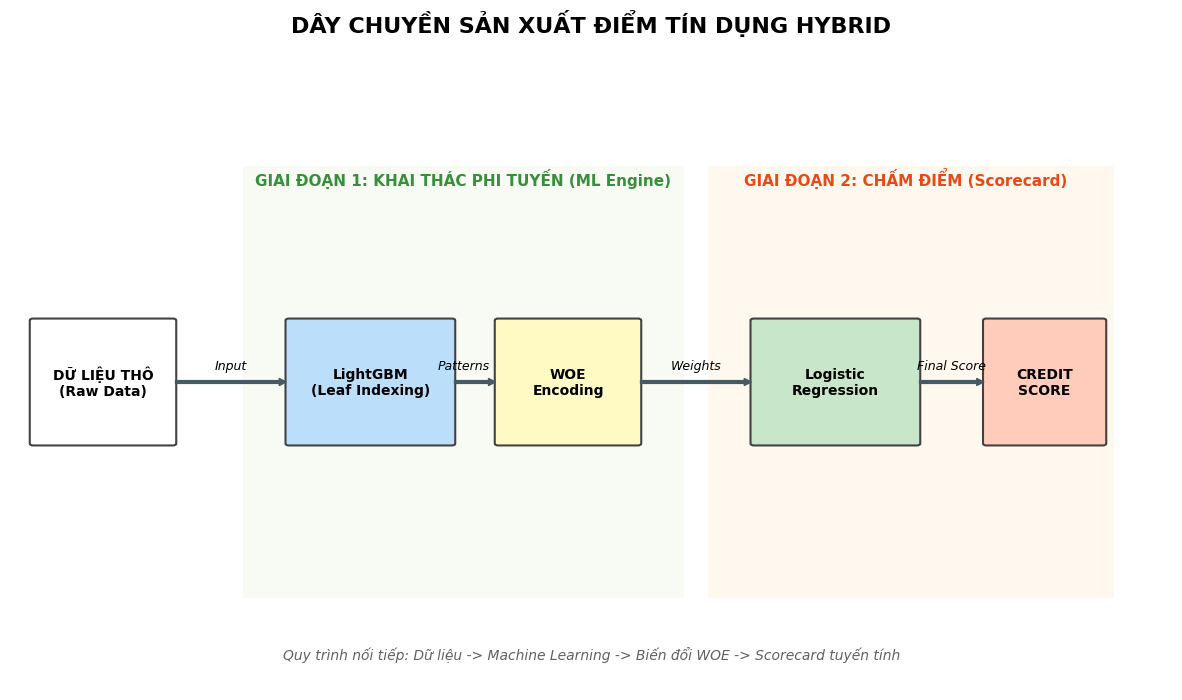

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_hybrid_pipeline():
    fig, ax = plt.subplots(figsize=(15, 8))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.axis('off')

    # 1. Vẽ các vùng nền (Background Groups) để tạo tính kết nối
    # Vùng 1: Feature Engineering & ML
    group1 = patches.Rectangle((20, 15), 38, 70, linewidth=0, edgecolor='none', facecolor='#f1f8e9', alpha=0.5, zorder=1)
    ax.add_patch(group1)
    ax.text(39, 82, "GIAI ĐOẠN 1: KHAI THÁC PHI TUYẾN (ML Engine)", ha='center', fontsize=11, fontweight='bold', color='#388e3c')

    # Vùng 2: Financial Scoring
    group2 = patches.Rectangle((60, 15), 35, 70, linewidth=0, edgecolor='none', facecolor='#fff3e0', alpha=0.5, zorder=1)
    ax.add_patch(group2)
    ax.text(77, 82, "GIAI ĐOẠN 2: CHẤM ĐIỂM (Scorecard)", ha='center', fontsize=11, fontweight='bold', color='#e64a19')

    # Helper to draw components
    def draw_node(x, y, w, h, text, color, z=2):
        rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.3",
                                     edgecolor="#424242", facecolor=color, linewidth=1.5, zorder=z)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center',
                fontsize=10, fontweight='bold', wrap=True, zorder=z+1)

    # --- CÁC THÀNH PHẦN (NODES) ---
    # Input
    draw_node(2, 40, 12, 20, "DỮ LIỆU THÔ\n(Raw Data)", "#ffffff")

    # Step 1 & 2
    draw_node(24, 40, 14, 20, "LightGBM\n(Leaf Indexing)", "#bbdefb")

    # Step 3
    draw_node(42, 40, 12, 20, "WOE\nEncoding", "#fff9c4")

    # Step 4
    draw_node(64, 40, 14, 20, "Logistic\nRegression", "#c8e6c9")

    # Output
    draw_node(84, 40, 10, 20, "CREDIT\nSCORE", "#ffccbc")

    # --- CÁC MŨI TÊN KẾT NỐI (FLOWS) ---
    arrow_props = dict(arrowstyle='simple', color='#455a64', lw=1)

    # Flow chính
    ax.annotate("", xy=(24, 50), xytext=(14, 50), arrowprops=arrow_props)
    ax.annotate("", xy=(42, 50), xytext=(38, 50), arrowprops=arrow_props)
    ax.annotate("", xy=(64, 50), xytext=(54, 50), arrowprops=arrow_props)
    ax.annotate("", xy=(84, 50), xytext=(78, 50), arrowprops=arrow_props)

    # Mô tả các bước
    ax.text(19, 52, "Input", fontsize=9, style='italic', ha='center')
    ax.text(39, 52, "Patterns", fontsize=9, style='italic', ha='center')
    ax.text(59, 52, "Weights", fontsize=9, style='italic', ha='center')
    ax.text(81, 52, "Final Score", fontsize=9, style='italic', ha='center')

    # Chú thích cuối
    plt.title("DÂY CHUYỀN SẢN XUẤT ĐIỂM TÍN DỤNG HYBRID", fontsize=16, fontweight='bold', pad=30)
    ax.text(50, 5, "Quy trình nối tiếp: Dữ liệu -> Machine Learning -> Biến đổi WOE -> Scorecard tuyến tính",
            ha='center', fontsize=10, color='#616161', style='italic')

    plt.show()

draw_hybrid_pipeline()

------------------------------------------
# 5. Kết luận

### Tổng kết lại những ý chính

Bài báo cáo này đã đi qua 3 giai đoạn chính:

**Giai đoạn 1: Làm sạch và chuẩn bị dữ liệu**

Nhóm bắt đầu với 10.345 giao dịch BNPL từ 6 quốc gia. Dữ liệu này không có giá trị thiếu (missing values), nhưng có vấn đề về độ lệch (skewness) và ngoại lai (outliers). Cụ thể:
- Cột `monthly_income` bị lệch phải rất nhiều (skew = 0.81) nên nhóm đề xuất dùng Log Transform để làm nó bình thường hơn, dàn trải đều hơn
- Cột `debt_to_income_ratio` cũng lệch nên dùng Sqrt Transform
- Xử lý ngoại lai ở `monthly_income` bằng Winsorization - giới hạn ở percentile 99%

Kết quả là dữ liệu được làm sạch và sẵn sàng cho phân tích.

**Giai đoạn 2: Khám phá và phân tích dữ liệu (EDA)**

Đây là phần quan trọng nhất của báo cáo. Nhóm đã phát hiện ra 6 thực trạng chính:

1. **Số lần lỡ thanh toán là yếu tố quyết định nhất**: Khách hàng không bao giờ lỡ thanh toán có tỷ lệ vỡ nợ 39%, nhưng nếu lỡ 5 lần thì tỷ lệ tăng lên tới 91%. Đây rõ ràng là một tín hiệu rất mạnh.

2. **Tỷ lệ nợ trên thu nhập (DTI) rất quan trọng**: Nếu DTI > 30%, tỷ lệ vỡ nợ là 58%, còn nếu DTI ≤ 30% thì chỉ 32%. Điều này cho thấy mức thu nhập tuyệt đối không quan trọng bằng bao nhiêu người mượn so với thu nhập của họ.

3. **Loại hình việc làm ảnh hưởng lớn**: Người thất nghiệp và sinh viên có tỷ lệ vỡ nợ cao (62% và 58%), còn người có việc làm ổn định (salaried) chỉ 35%. Điều này dễ hiểu vì dòng tiền không ổn định thì khó trả nợ.

4. **Kỳ hạn trả góp dài không phải là điều tốt**: Ngược lại với trực giác, khách hàng chọn trả 12 kỳ lại có tỷ lệ vỡ nợ cao hơn (50%) so với trả 3 kỳ (25%). Có vẻ những người chọn kỳ dài là vì họ không đủ khả năng trả, chứ không phải vì họ muốn linh hoạt.

5. **Điểm tín dụng truyền thống không hiệu quả**: Nhóm đã phát hiện ra rằng `credit_score` có tương quan rất yếu (-0.18) với việc vỡ nợ. Hai nhóm (người vỡ nợ vs người an toàn) có phân phối điểm tín dụng gần như giống nhau. Điều này có nghĩa credit score từ ngân hàng không phải công cụ tốt để dự đoán rủi ro BNPL.

6. **Tần suất sử dụng app không liên quan đến khả năng trả nợ**: Có người dùng app rất thường xuyên nhưng vẫn vỡ nợ. Vậy nên không thể dùng điều này làm tiêu chí đánh giá rủi ro.

**Giai đoạn 3: Lập kế hoạch xây dựng mô hình**

Dựa trên những phát hiện ở trên, nhóm lên kế hoạch xây dựng mô hình dự đoán rủi ro BNPL với kỹ thuật Hybrid (Sự kết hợp của hai thuật toán):
- Logistic Regression: Dễ dùng, dễ giải thích
- LightGBM: Nhanh, tiết kiệm bộ nhớ, hiệu suất cao

Các biến đầu vào phải được chuẩn bị khác nhau tùy vào từng loại mô hình. Trong các chỉ số đánh giá mô hình, nhóm cũng đề xuất dùng AUC-ROC làm chỉ số đánh giá chính vì dữ liệu có sự bất cân xứng (không phải nửa là vỡ nợ, nửa là an toàn).


### Ý nghĩa thực tế

Kết quả của phân tích này rất hữu ích cho các nền tảng BNPL. Thay vì dùng các tiêu chí đơn giản như "điểm tín dụng cao" hoặc "dùng app thường xuyên", họ nên tập trung vào:

- **Lịch sử thanh toán**: Nếu một khách hàng từng lỡ thanh toán nhiều lần, rủi ro sẽ rất cao. Cần phải rất cẩn thận hoặc từ chối.
- **Tỷ lệ nợ trên thu nhập**: Nên đặt giới hạn riêng cho từng khách hàng dựa vào DTI của họ. Nếu DTI > 30%, nên hạn chế số tiền và số kỳ hạn.
- **Loại hình công việc**: Những người thất nghiệp hoặc sinh viên cần được xem xét kỹ hơn.
- **Cảnh báo từ kỳ hạn dài**: Nếu khách hàng chọn 12 kỳ, cần kiểm tra thêm dù số tiền có vẻ hợp lý.

### Hạn chế của bài báo cáo

1. **Dữ liệu là synthetic**: Bộ dữ liệu từ Kaggle được tổng hợp, không phải từ hệ thống thực tế của một nền tảng BNPL. Vì vậy những con số cụ thể có thể khác với thực tế.

2. **Chưa thử từng mô hình**: Bài báo cáo này chỉ lên kế hoạch xây dựng mô hình, chưa thực sự huấn luyện và so sánh hiệu suất của 4 thuật toán. Điều đó sẽ là bước tiếp theo.

3. **Thiếu dữ liệu bổ sung**: Trong thực tế, còn nhiều yếu tố khác có thể ảnh hưởng đến rủi ro như: dữ liệu từ ngân hàng, thông tin từ mạng xã hội, điều kiện kinh tế vĩ mô, v.v. Nhưng bộ dữ liệu hiện tại không có.

4. **Chưa kiểm tra công bằng (fairness)**: Hiện tại những ý tưởng nêu trên chỉ là chiến lược, chưa kiểm tra xem mô hình có thiên vị theo giới tính, tuổi hay vị trí địa lý hay không. Đây là vấn đề quan trọng trong thực tế.

### Hướng phát triển tiếp theo

1. **Thử xây dựng thực sự các mô hình** và so sánh hiệu suất trên test set. Dự kiến XGBoost hoặc LightGBM sẽ cho kết quả tốt nhất.

2. **Thu thập dữ liệu thực tế** từ các nền tảng BNPL (nếu có thể) để retrain mô hình. Dữ liệu synthetic chỉ là bước đầu.

3. **Thêm các biến mới**: Khoảng thời gian từ lần thanh toán gần nhất, số lần giao dịch liên tiếp, mô hình hóa theo thời gian, v.v.

4. **Kiểm tra công bằng**: Đảm bảo mô hình không phân biệt đối xử với nhóm nào.

5. **Xây dựng hệ thống giám sát**: Khi mô hình được triển khai, cần liên tục theo dõi xem hiệu suất có giảm sút hay không (model drift) để kịp thời retrain.

### Tổng kết

Bài báo cáo này cung cấp những insight hữu ích về rủi ro tín dụng BNPL và một roadmap rõ ràng để xây dựng mô hình dự đoán. Mặc dù chưa triển khai mô hình thực tế, nhưng phân tích dữ liệu kỹ lưỡng của nhóm đã cho thấy những yếu tố nào thực sự quan trọng và những yếu tố nào tương đối vô dụng.

